# 🚕 Ride-Hailing Business Performance Analysis

## End-to-End Data Analytics Project

Analisis performa bisnis layanan **ride-hailing** menggunakan **150.000 data pemesanan (booking)** di wilayah **National Capital Region (NCR), India**. Proyek ini bertujuan mengidentifikasi titik kehilangan permintaan (*demand leakage*) pada proses pemesanan, mengukur dampak bisnisnya, serta menghasilkan rekomendasi berbasis data untuk meningkatkan konversi, efisiensi operasional, dan pendapatan.

Proyek ini dikembangkan mengikuti **end-to-end data analytics workflow**, mulai dari pemahaman bisnis, pengolahan data, analisis statistik, eksplorasi data, SQL analytics, machine learning, hingga penyusunan insight dan rekomendasi bisnis.

---

## 📌 Project Workflow

| Tahap | Aktivitas |
|:---:|---|
| **1** | Business Understanding |
| **2** | Data Understanding |
| **3** | Data Quality Assessment |
| **4** | Data Cleaning & Data Preparation |
| **5** | Feature Engineering |
| **6** | Exploratory Data Analysis (EDA) |
| **7** | Statistical Analysis |
| **8** | SQL Analytics (SQLite) |
| **9** | Machine Learning |
| **10** | Data Modeling & Export Clean Dataset |
| **11** | Power BI Dashboard Development |
| **12** | Business Insights & Recommendations |

---

## 🎯 Project Objectives

- Menganalisis performa funnel pemesanan layanan ride-hailing.
- Mengidentifikasi faktor utama yang menyebabkan pembatalan dan kegagalan perjalanan.
- Mengukur dampak finansial akibat *demand leakage*.
- Menganalisis pola permintaan berdasarkan waktu, lokasi, metode pembayaran, dan tipe kendaraan.
- Mengembangkan model machine learning untuk memprediksi kemungkinan pembatalan perjalanan.
- Membangun dashboard interaktif untuk memantau KPI bisnis.
- Memberikan rekomendasi strategis berbasis data guna meningkatkan performa operasional dan pendapatan.

---

## 🛠️ Technology Stack

- **Python** (Pandas, NumPy, Matplotlib, SciPy, Scikit-learn)
- **SQL (SQLite)**
- **Power BI & DAX**
- **Jupyter Notebook**

---

## 📂 Dataset

| Informasi | Detail |
|---|---|
| **Dataset** | Uber Ride Analytics Dashboard |
| **Source** | Kaggle |
| **File** | `ncr_ride_bookings.csv` |
| **Observations** | 150,000 booking records |


# 1. Business Understanding

## 1.1 Konteks Bisnis

Layanan **ride-hailing** merupakan bisnis **two-sided marketplace** yang menghubungkan penumpang dengan pengemudi melalui platform digital. Pendapatan perusahaan hanya diperoleh ketika proses pemesanan berhasil diselesaikan menjadi perjalanan (*completed trip*). Oleh karena itu, setiap pemesanan yang gagal tidak hanya menyebabkan hilangnya potensi pendapatan (*revenue leakage*), tetapi juga dapat menurunkan kepuasan pelanggan, efisiensi operasional, serta tingkat kepercayaan terhadap platform.

Kegagalan pemesanan dapat terjadi pada berbagai tahap *booking funnel*, seperti tidak tersedianya pengemudi (*No Driver Found*), pembatalan oleh pengemudi, pembatalan oleh pelanggan, maupun perjalanan yang tidak selesai (*Incomplete*). Memahami titik-titik kegagalan tersebut menjadi langkah penting untuk meningkatkan **Booking Completion Rate** dan mengoptimalkan kinerja bisnis secara keseluruhan.

---

## 1.2 Permasalahan Bisnis

Perusahaan perlu mengetahui pada tahap mana kehilangan permintaan (*demand leakage*) paling banyak terjadi, seberapa besar dampak finansial yang ditimbulkan, serta faktor-faktor yang memengaruhi keberhasilan maupun kegagalan suatu pemesanan. Hasil analisis ini diharapkan dapat menjadi dasar dalam menentukan prioritas perbaikan operasional dan mendukung pengambilan keputusan berbasis data.

---

## 1.3 Pertanyaan Bisnis

Analisis ini bertujuan untuk menjawab beberapa pertanyaan bisnis berikut.

1. Bagaimana performa *booking funnel* dan berapa nilai **Booking Completion Rate**?
2. Berapa besar potensi pendapatan yang hilang (*revenue leakage*) akibat pembatalan atau kegagalan pemesanan?
3. Apakah jenis kendaraan, metode pembayaran, dan waktu pemesanan memengaruhi tingkat keberhasilan perjalanan?
4. Kapan periode permintaan tertinggi terjadi dan bagaimana pola permintaannya berdasarkan waktu?
5. Apa penyebab utama pembatalan dari sisi pelanggan maupun pengemudi?
6. Bagaimana karakteristik pelanggan berdasarkan perilaku pemesanan dan tingkat retensinya?
7. Dapatkah status pemesanan diprediksi menggunakan teknik *machine learning* berdasarkan data yang tersedia?

---

## 1.4 Tujuan Analisis

Proyek ini bertujuan untuk:

- Mengevaluasi performa *booking funnel* secara menyeluruh.
- Mengidentifikasi faktor utama penyebab kegagalan dan pembatalan perjalanan.
- Mengukur dampak bisnis melalui analisis pendapatan dan *revenue leakage*.
- Menganalisis pola permintaan berdasarkan waktu, lokasi, metode pembayaran, dan jenis kendaraan.
- Mengembangkan model *machine learning* untuk memprediksi kemungkinan pembatalan atau kegagalan pemesanan.
- Menyusun rekomendasi bisnis berbasis data untuk meningkatkan efisiensi operasional, pengalaman pelanggan, dan pendapatan perusahaan.

---

## 1.5 Indikator Kinerja Utama (Key Performance Indicators)

**Indikator Utama**

- Booking Completion Rate

**Indikator Pendukung**

- Total Bookings
- Completed Trips
- Cancellation Rate
- Driver Cancellation Rate
- Customer Cancellation Rate
- Revenue
- Revenue Leakage
- Average Booking Value
- Average Ride Distance
- Customer Retention Rate

## 2. Setup — Import Library & Konfigurasi

Pada tahap ini dilakukan impor seluruh library yang digunakan selama proses analisis. Library dikelompokkan berdasarkan fungsinya untuk meningkatkan keterbacaan dan memudahkan reproduksibilitas notebook.

Library yang digunakan meliputi:

- **Manipulasi Data:** `pandas`, `numpy`
- **Visualisasi Data:** `matplotlib`, `seaborn`, `plotly`
- **Analisis Statistik:** `scipy`, `statsmodels`
- **Machine Learning:** `scikit-learn`
- **Basis Data:** `sqlite3`
- **Utilitas Pendukung:** library standar Python untuk pengelolaan file, tanggal, dan konfigurasi.

Struktur impor yang terorganisasi memudahkan proses pengembangan, pemeliharaan kode, serta memastikan seluruh tahapan analisis dapat dijalankan secara konsisten pada lingkungan yang berbeda.

In [1]:
# Import libraries

# Standard library
import warnings
from pathlib import Path
import sqlite3

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except ImportError:
    pass

# Statistical analysis
from scipy import stats
from scipy.stats import (
    chi2_contingency, f_oneway, kendalltau, kruskal,
    kstest, mannwhitneyu, normaltest, pearsonr,
    shapiro, spearmanr, ttest_ind,
)

!pip install statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine learning
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

In [2]:
# Visualization settings
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Display settings
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", None)

# Color palette
COLORS = {
    "primary": "#2563EB",
    "success": "#05A357",
    "warning": "#F6B000",
    "danger": "#E32934",
    "driver": "#DC2626",
    "customer": "#EA580C",
    "purple": "#7C3AED",
    "teal": "#0D9488",
    "neutral": "#8A8A8A",
}

PALETTE = [
    COLORS["primary"],
    COLORS["success"],
    COLORS["warning"],
    COLORS["danger"],
    COLORS["purple"],
    COLORS["teal"],
    COLORS["customer"],
]


def annotate_barh(ax, values, fmt="{:,.0f}", pad_frac=0.01):
    """Add value labels to horizontal bar charts."""
    span = max(values) if len(values) else 1
    for i, value in enumerate(values):
        ax.text(
            value + span * pad_frac,
            i,
            fmt.format(value),
            va="center",
            fontsize=9,
            fontweight="bold",
        )


def annotate_barv(ax, fmt="{:,.0f}", pad_frac=0.01):
    """Add value labels to vertical bar charts."""
    ymax = ax.get_ylim()[1]
    for patch in ax.patches:
        height = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + ymax * pad_frac,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

## 3. Data Loading & Data Understanding

### 3.1 Memuat Dataset

In [3]:
from pathlib import Path

# Load dataset
DATA_PATH = Path(r"C:\Users\radit\Downloads\Project Baru\Ride Hailing Project\ncr_ride_bookings.csv")

df = pd.read_csv(DATA_PATH)

# Preview dataset
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.90,14.00,NaN,NaN,NaN,NaN,1.00,Vehicle Breakdown,237.00,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.40,25.80,NaN,NaN,NaN,NaN,NaN,NaN,627.00,13.58,4.90,4.90,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.10,28.50,NaN,NaN,NaN,NaN,NaN,NaN,416.00,34.02,4.60,5.00,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.30,19.60,NaN,NaN,NaN,NaN,NaN,NaN,737.00,48.21,4.10,4.30,UPI


### 3.2 Kamus Data (*Data Dictionary*)

Dataset terdiri dari **21 variabel** yang merepresentasikan informasi pemesanan, karakteristik perjalanan, detail pelanggan dan pengemudi, hingga status akhir setiap transaksi. Pemahaman terhadap setiap variabel diperlukan sebagai dasar dalam proses eksplorasi data, analisis bisnis, dan pengembangan model.

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| `Date`, `Time` | Datetime | Tanggal dan waktu pemesanan dibuat. |
| `Booking ID` | Identifier | Identitas unik setiap pemesanan. |
| `Booking Status` | Kategorikal | Status akhir pemesanan, seperti *Completed*, *Cancelled by Driver*, *Cancelled by Customer*, *No Driver Found*, atau *Incomplete*. |
| `Customer ID` | Identifier | Identitas unik pelanggan. |
| `Vehicle Type` | Kategorikal | Jenis kendaraan yang dipilih pelanggan. |
| `Pickup Location` | Kategorikal | Lokasi penjemputan. |
| `Drop Location` | Kategorikal | Lokasi tujuan perjalanan. |
| `Avg VTAT` | Numerik | *Vehicle Turn-Around Time*, yaitu rata-rata waktu yang dibutuhkan pengemudi untuk mencapai lokasi penjemputan (menit). |
| `Avg CTAT` | Numerik | *Customer Turn-Around Time*, yaitu rata-rata durasi perjalanan sejak penjemputan hingga selesai (menit). |
| `Booking Value` | Numerik | Nilai atau tarif pemesanan (₹). |
| `Ride Distance` | Numerik | Jarak perjalanan (km). |
| `Driver Ratings` | Numerik | Rating yang diberikan pelanggan kepada pengemudi (1–5). |
| `Customer Rating` | Numerik | Rating yang diberikan pengemudi kepada pelanggan (1–5). |
| `Payment Method` | Kategorikal | Metode pembayaran yang digunakan pelanggan. |
| `Cancelled Rides by Customer` | Kategorikal | Indikator pembatalan oleh pelanggan. |
| `Customer Cancellation Reason` | Teks | Alasan pembatalan yang dilakukan pelanggan. |
| `Cancelled Rides by Driver` | Kategorikal | Indikator pembatalan oleh pengemudi. |
| `Driver Cancellation Reason` | Teks | Alasan pembatalan yang dilakukan pengemudi. |
| `Incomplete Rides` | Kategorikal | Indikator perjalanan yang tidak selesai. |
| `Incomplete Rides Reason` | Teks | Alasan perjalanan tidak dapat diselesaikan. |

> **Catatan**
>
> Beberapa variabel bersifat **kondisional (structural fields)**, sehingga hanya memiliki nilai pada status pemesanan tertentu. Sebagai contoh, kolom alasan pembatalan hanya terisi apabila pemesanan dibatalkan, sedangkan kolom *Incomplete Rides Reason* hanya terisi pada perjalanan yang berstatus *Incomplete*. Kondisi ini merupakan karakteristik data, bukan indikasi kesalahan, dan akan dievaluasi lebih lanjut pada tahap **Data Quality Assessment**.

In [4]:
# Struktur teknis dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  10500 non-null 

In [5]:
# Ringkasan statistik awal (kolom numerik yang sudah terbaca sebagai angka)
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,150000,365,2024-11-16,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,150000,62910,17:44:57,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking ID,150000,148767,"""CNR7908610""",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking Status,150000,5,Completed,93000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,150000,148788,"""CID6468528""",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Type,150000,7,Auto,37419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pickup Location,150000,176,Khandsa,949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Drop Location,150000,176,Ashram,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Avg VTAT,"139,500.00",NaN,NaN,NaN,8.46,3.77,2.00,5.30,8.30,11.30,20.00
Avg CTAT,"102,000.00",NaN,NaN,NaN,29.15,8.90,10.00,21.60,28.80,36.80,45.00


# 4. Data Quality Assessment

Kualitas data merupakan aspek penting yang harus dievaluasi sebelum melakukan analisis maupun pengembangan model. Pada tahap ini dilakukan pemeriksaan terhadap kelengkapan, konsistensi, validitas, serta struktur data untuk memastikan dataset layak digunakan dan menghasilkan insight yang dapat dipercaya.

Evaluasi kualitas data mencakup beberapa aspek utama, yaitu:

- Kelengkapan data (*missing values*)
- Duplikasi data
- Kesesuaian tipe data
- Konsistensi nilai antarvariabel
- Identifikasi nilai ekstrem (*outlier*)

---

## 4.1 Normalisasi Awal & Ringkasan Kualitas

Sebelum melakukan pemeriksaan kualitas data, dilakukan proses normalisasi awal terhadap beberapa nilai yang belum sesuai dengan format analisis.

Beberapa permasalahan yang ditemukan pada dataset antara lain:

- Nilai pada kolom identitas, seperti **Booking ID** dan **Customer ID**, masih mengandung tanda kutip ganda (`"""..."`), sehingga perlu dibersihkan agar formatnya konsisten.
- Nilai kosong direpresentasikan sebagai string `"null"` alih-alih nilai `NaN`, sehingga perlu dikonversi agar dapat dikenali sebagai *missing values* oleh Python.

Normalisasi ini bertujuan untuk memastikan proses identifikasi *missing values*, validasi data, serta analisis pada tahap berikutnya dapat dilakukan secara akurat dan konsisten.

In [6]:
# Membersihkan data
df["Booking ID"] = df["Booking ID"].str.replace('"', "", regex=False).str.strip()
df["Customer ID"] = df["Customer ID"].str.replace('"', "", regex=False).str.strip()
df.replace("null", np.nan, inplace=True)

# Ringkasan kualitas data
quality = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(1),
    "Nilai Unik": df.nunique(),
    "Tipe Data": df.dtypes
}).sort_values("Missing (%)", ascending=False)

quality

,Missing,Missing (%),Nilai Unik,Tipe Data
Incomplete Rides Reason,141000,94.00,3,str
Incomplete Rides,141000,94.00,1,float64
Reason for cancelling by Customer,139500,93.00,5,str
Cancelled Rides by Customer,139500,93.00,1,float64
Cancelled Rides by Driver,123000,82.00,1,float64
Driver Cancellation Reason,123000,82.00,4,str
Driver Ratings,57000,38.00,21,float64
Customer Rating,57000,38.00,21,float64
Avg CTAT,48000,32.00,351,float64
Ride Distance,48000,32.00,4901,float64


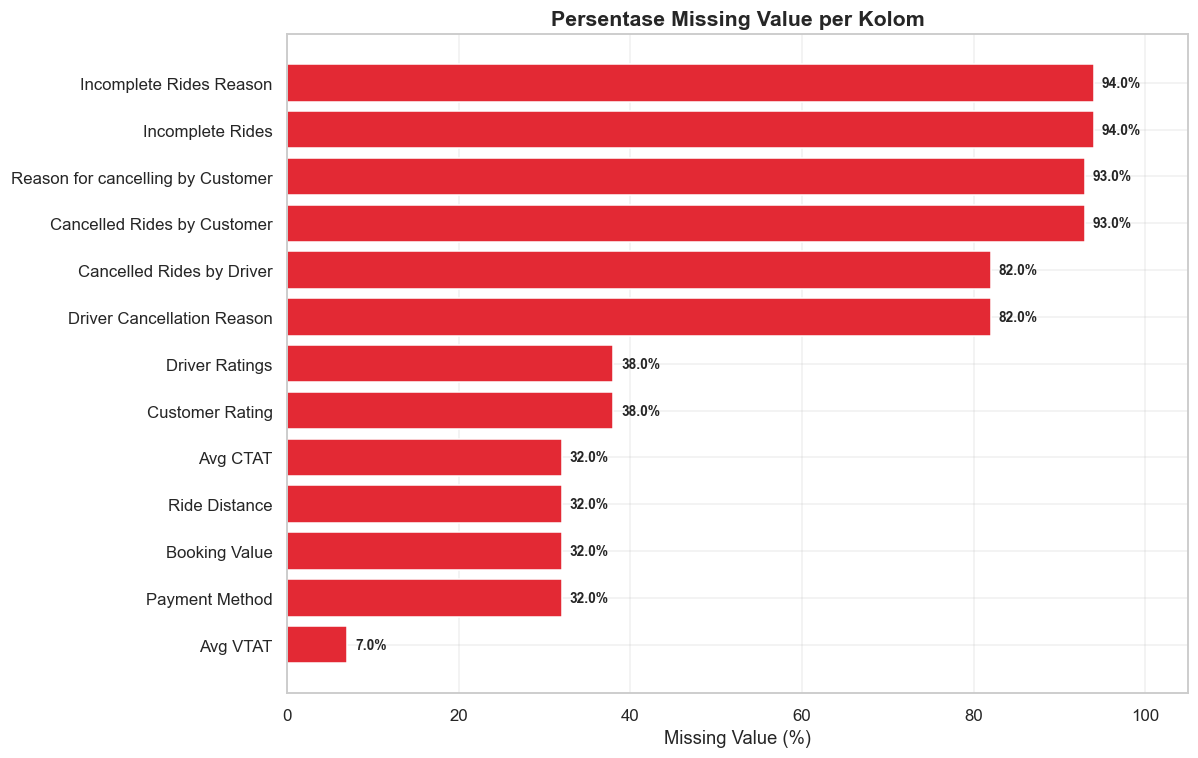

In [7]:
# Persentase missing value per kolom
missing_percentage = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_percentage = missing_percentage[missing_percentage > 0]

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    missing_percentage.index[::-1],
    missing_percentage.values[::-1],
    color=COLORS["danger"]
)

annotate_barh(
    ax,
    missing_percentage.values[::-1],
    fmt="{:.1f}%"
)

ax.set_title("Persentase Missing Value per Kolom")
ax.set_xlabel("Missing Value (%)")
ax.set_ylabel("")
ax.set_xlim(0, 105)

plt.tight_layout()
plt.show()

# 5. Data Cleaning & Type Coercion

Setelah proses **Data Quality Assessment**, dilakukan tahapan pembersihan data untuk memastikan seluruh variabel memiliki format yang konsisten dan siap digunakan pada proses analisis, visualisasi, maupun pengembangan model machine learning.

Proses pembersihan difokuskan pada perbaikan struktur data tanpa mengubah makna bisnis dari setiap observasi. Seluruh transformasi dilakukan secara sistematis agar kualitas dan integritas data tetap terjaga.

---

## 5.1 Data Cleaning

Tahapan pembersihan data meliputi beberapa proses berikut.

- Mengonversi kolom numerik yang masih tersimpan sebagai **string** ke dalam tipe data numerik yang sesuai.
- Menggabungkan kolom **Date** dan **Time** menjadi satu kolom **Datetime** untuk memudahkan analisis berbasis waktu.
- Menyesuaikan tipe data setiap variabel agar sesuai dengan karakteristik datanya, seperti numerik, kategorikal, maupun datetime.
- Memastikan nilai yang tidak valid akibat proses konversi ditangani secara konsisten menggunakan nilai `NaN`.

---

## 5.2 Validasi Integritas Data

Setelah proses pembersihan selesai, dilakukan serangkaian pemeriksaan untuk memastikan tidak terdapat nilai yang bertentangan dengan aturan bisnis (*business rules*).

Validasi yang dilakukan meliputi:

- Memastikan seluruh nilai **Booking Value** dan **Ride Distance** tidak bernilai negatif.
- Memastikan **Driver Ratings** dan **Customer Rating** berada pada rentang nilai **1–5**.
- Memastikan seluruh kolom **Datetime** berhasil dikonversi tanpa menghasilkan nilai yang gagal diproses.
- Memverifikasi bahwa perubahan tipe data telah berhasil diterapkan pada seluruh variabel yang relevan.

Tahap validasi ini bertujuan untuk menjaga integritas dataset sehingga hasil analisis pada tahap selanjutnya dapat diandalkan dan merepresentasikan kondisi bisnis secara akurat.

In [8]:
# Mengubah kolom numerik ke tipe data numerik
numeric_columns = [
    "Avg VTAT",
    "Avg CTAT",
    "Booking Value",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating",
]

df[numeric_columns] = df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

# Menggabungkan kolom tanggal dan waktu
df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    errors="coerce"
)

# Pemeriksaan validitas data
pd.DataFrame({
    "Pemeriksaan": [
        "Booking Value negatif",
        "Ride Distance = 0",
        "Driver Rating > 5",
        "Driver Rating < 1",
        "Datetime tidak valid"
    ],
    "Jumlah": [
        (df["Booking Value"] < 0).sum(),
        (df["Ride Distance"] == 0).sum(),
        (df["Driver Ratings"] > 5).sum(),
        (df["Driver Ratings"] < 1).sum(),
        df["Datetime"].isna().sum()
    ]
})

,Pemeriksaan,Jumlah
0,Booking Value negatif,0
1,Ride Distance = 0,0
2,Driver Rating > 5,0
3,Driver Rating < 1,0
4,Datetime tidak valid,0


### 5.1 Deteksi Outlier (Metode IQR)

Setelah proses pembersihan data, dilakukan identifikasi **outlier** pada variabel numerik menggunakan metode **Interquartile Range (IQR)** dengan aturan **1.5 × IQR**. Analisis difokuskan pada data dengan status **Completed** agar distribusi nilai merepresentasikan perjalanan yang benar-benar berhasil diselesaikan.

Deteksi outlier bertujuan untuk memahami karakteristik distribusi data serta mengidentifikasi observasi yang berada di luar pola umum. Pada tahap ini, outlier **tidak langsung dihapus**, karena nilai yang tinggi pada tarif maupun jarak perjalanan masih dapat merepresentasikan kondisi bisnis yang valid, seperti perjalanan jarak jauh atau tarif pada periode permintaan tinggi (*peak demand*).

Hasil identifikasi outlier akan digunakan sebagai bahan evaluasi pada analisis statistik dan interpretasi bisnis, bukan sebagai dasar otomatis untuk menghilangkan data dari proses analisis.

In [9]:
# Deteksi outlier dengan metode IQR
completed = df[df["Booking Status"] == "Completed"].copy()

columns = [
    "Booking Value",
    "Ride Distance",
    "Avg VTAT",
    "Avg CTAT",
]

outlier_summary = []

for col in columns:
    q1 = completed[col].quantile(0.25)
    q3 = completed[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((completed[col] < lower) | (completed[col] > upper)).sum()

    outlier_summary.append({
        "Kolom": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Batas Bawah": lower,
        "Batas Atas": upper,
        "Jumlah Outlier": outliers,
        "Persentase Outlier (%)": round(
            outliers / completed[col].notna().sum() * 100,
            2
        ),
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,Kolom,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase Outlier (%)
0,Booking Value,234.00,689.00,455.00,-448.50,"1,371.50",3127,3.36
1,Ride Distance,14.10,37.94,23.84,-21.66,73.71,0,0.00
2,Avg VTAT,5.30,11.80,6.50,-4.45,21.55,0,0.00
3,Avg CTAT,22.60,37.50,14.90,0.25,59.85,0,0.00


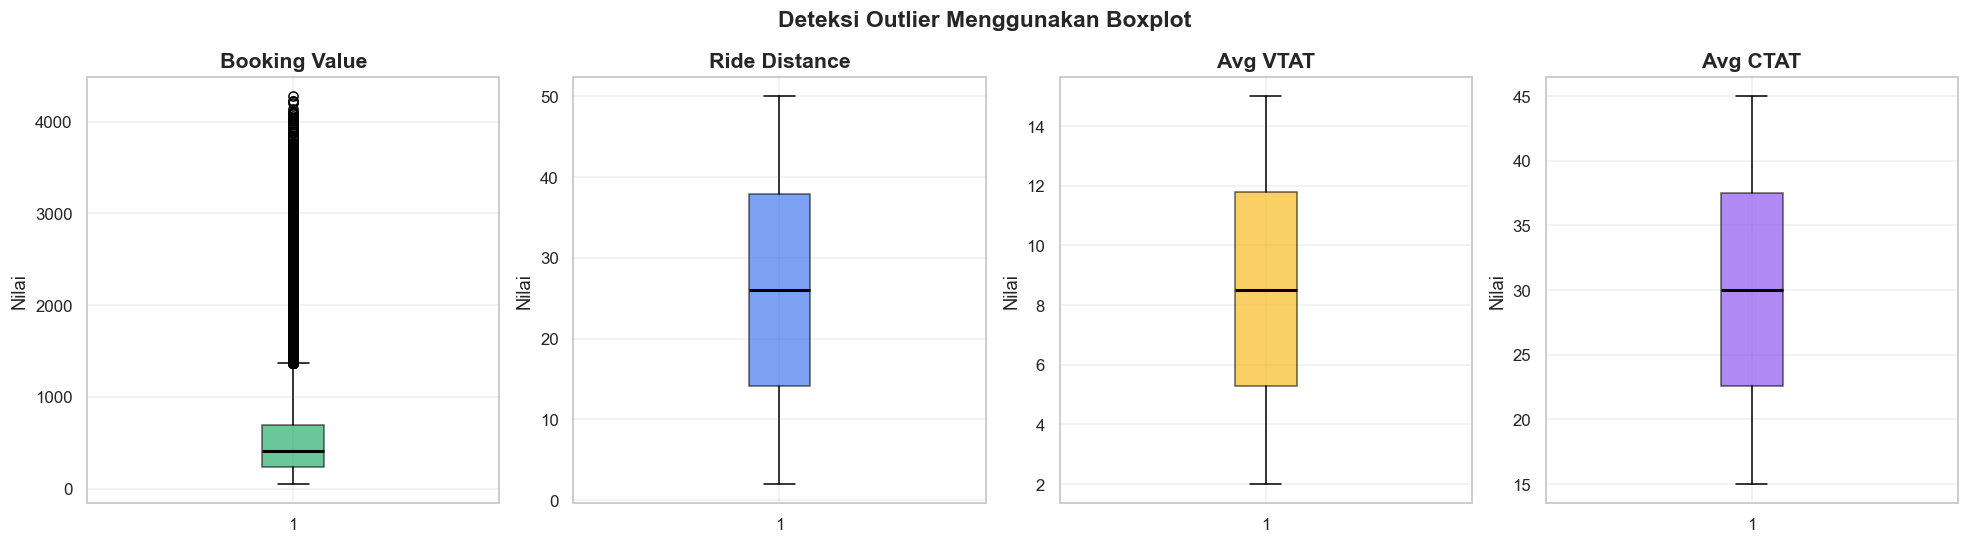

In [10]:
# Visualisasi outlier menggunakan boxplot
columns = [
    "Booking Value",
    "Ride Distance",
    "Avg VTAT",
    "Avg CTAT",
]

colors = [
    COLORS["success"],
    COLORS["primary"],
    COLORS["warning"],
    COLORS["purple"],
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, column in enumerate(columns):
    axes[i].boxplot(
        completed[column].dropna(),
        patch_artist=True,
        boxprops={"facecolor": colors[i], "alpha": 0.6},
        medianprops={"color": "black", "linewidth": 2},
    )

    axes[i].set_title(column)
    axes[i].set_ylabel("Nilai")

fig.suptitle(
    "Deteksi Outlier Menggunakan Boxplot",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

# 6. Feature Engineering

Pada tahap ini dilakukan proses **feature engineering** untuk membentuk variabel baru yang dapat memperkaya analisis serta meningkatkan kemampuan model dalam menangkap pola yang terdapat pada data. Seluruh fitur turunan dibangun berdasarkan informasi yang sudah tersedia tanpa mengubah nilai asli pada dataset.

Fitur-fitur yang dihasilkan dirancang untuk mendukung analisis perilaku permintaan, performa operasional, karakteristik perjalanan, serta evaluasi bisnis secara lebih komprehensif.

---

## 6.1 Pembuatan Variabel Turunan

Beberapa kelompok fitur yang dibuat pada tahap ini meliputi:

### **Fitur Temporal**

Digunakan untuk menganalisis pola permintaan berdasarkan waktu.

- `Hour` : Jam pemesanan.
- `Weekday` : Hari dalam satu minggu.
- `Month` : Bulan pemesanan.
- `TimeOfDay` : Kategori waktu (Pagi, Siang, Sore, Malam).
- `Period` : Klasifikasi periode **Peak** dan **Off-Peak**.
- `is_weekend` : Penanda apakah pemesanan terjadi pada akhir pekan.

### **Fitur Kategorisasi**

Digunakan untuk mempermudah analisis berdasarkan kelompok nilai.

- `DistanceBand` : Kategori jarak perjalanan.
- `RevenueBand` : Kategori nilai pemesanan berdasarkan tarif.

### **Fitur Operasional dan Finansial**

Digunakan untuk mengevaluasi karakteristik perjalanan.

- `PricePerKm` : Tarif rata-rata per kilometer.
- `Route` : Kombinasi lokasi penjemputan dan tujuan perjalanan.

### **Fitur Status Pemesanan**

Digunakan untuk menyederhanakan analisis berdasarkan hasil akhir pemesanan.

- `is_completed` : Indikator perjalanan berhasil diselesaikan.
- `is_cancelled` : Indikator perjalanan dibatalkan.
- `Outcome` : Kategori hasil akhir pemesanan.
- `StatusCategory` : Penyederhanaan status pemesanan menjadi kategori yang lebih mudah dianalisis.

Pembuatan fitur-fitur tersebut bertujuan untuk meningkatkan kualitas analisis eksploratif, mempermudah proses segmentasi data, serta menyediakan variabel yang lebih informatif untuk analisis statistik dan pengembangan model machine learning.

In [11]:
# Feature Engineering

# Fitur waktu
df["Hour"] = df["Datetime"].dt.hour
df["Day"] = df["Datetime"].dt.day
df["Weekday"] = df["Datetime"].dt.day_name()
df["Month"] = df["Datetime"].dt.month_name()
df["MonthNum"] = df["Datetime"].dt.month
df["DOW"] = df["Datetime"].dt.dayofweek
df["is_weekend"] = df["DOW"].isin([5, 6])

# Periode perjalanan
peak_hours = list(range(7, 11)) + list(range(17, 21))

df["Period"] = np.where(
    df["Hour"].isin(peak_hours),
    "Peak",
    "Off-Peak",
)

# Kategori waktu
conditions = [
    (df["Hour"] >= 5) & (df["Hour"] < 12),
    (df["Hour"] >= 12) & (df["Hour"] < 17),
    (df["Hour"] >= 17) & (df["Hour"] < 21),
]

choices = [
    "Morning",
    "Afternoon",
    "Evening",
]

df["TimeOfDay"] = np.select(
    conditions,
    choices,
    default="Night",
)

# Kategori jarak
df["DistanceBand"] = pd.cut(
    df["Ride Distance"],
    bins=[0, 10, 20, 30, np.inf],
    labels=["0–10 km", "10–20 km", "20–30 km", ">30 km"],
)

# Kategori nilai booking
df["RevenueBand"] = pd.cut(
    df["Booking Value"],
    bins=[0, 250, 500, 750, np.inf],
    labels=["Low", "Medium", "High", "Premium"],
)

# Harga per kilometer
df["PricePerKm"] = (
    df["Booking Value"] / df["Ride Distance"]
).replace([np.inf, -np.inf], np.nan)

# Rute perjalanan
df["Route"] = (
    df["Pickup Location"]
    + " → "
    + df["Drop Location"]
)

# Status perjalanan
df["Outcome"] = df["Booking Status"].replace({
    "Cancelled by Customer": "Cancelled - Customer",
    "Cancelled by Driver": "Cancelled - Driver",
})

df["StatusCategory"] = df["Booking Status"].map({
    "Completed": "Success",
    "Cancelled by Driver": "Failed - Supply",
    "No Driver Found": "Failed - Supply",
    "Cancelled by Customer": "Failed - Demand",
    "Incomplete": "Failed - Mid-Ride",
})

# Flag status
df["is_completed"] = df["Booking Status"].eq("Completed")

df["is_cancelled"] = df["Booking Status"].isin([
    "Cancelled by Driver",
    "Cancelled by Customer",
])

# Preview fitur baru
df[
    [
        "Booking Status",
        "Hour",
        "TimeOfDay",
        "Period",
        "DistanceBand",
        "PricePerKm",
        "Outcome",
        "StatusCategory",
        "is_completed",
        "is_cancelled",
    ]
].head()

,Booking Status,Hour,TimeOfDay,Period,DistanceBand,PricePerKm,Outcome,StatusCategory,is_completed,is_cancelled
0,No Driver Found,12,Afternoon,Off-Peak,NaN,NaN,No Driver Found,Failed - Supply,False,False
1,Incomplete,18,Evening,Peak,0–10 km,41.36,Incomplete,Failed - Mid-Ride,False,False
2,Completed,8,Morning,Peak,10–20 km,46.17,Completed,Success,True,False
3,Completed,17,Evening,Peak,>30 km,12.23,Completed,Success,True,False
4,Completed,22,Night,Off-Peak,>30 km,15.29,Completed,Success,True,False


# 8. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data, mengidentifikasi pola, menemukan hubungan antarvariabel, serta memperoleh insight awal yang dapat mendukung analisis bisnis. Setiap visualisasi disertai interpretasi untuk menjelaskan temuan utama dan implikasinya terhadap performa bisnis ride-hailing.

Proses EDA disusun secara bertahap agar memberikan gambaran yang komprehensif mengenai kondisi data.


### 8.1 Analisis Univariat — Distribusi Status Pemesanan

Analisis ini bertujuan untuk melihat proporsi setiap **status pemesanan** sebagai gambaran awal performa **booking funnel**. Hasilnya digunakan untuk mengevaluasi **Booking Completion Rate** serta mengidentifikasi sumber utama *demand leakage*.

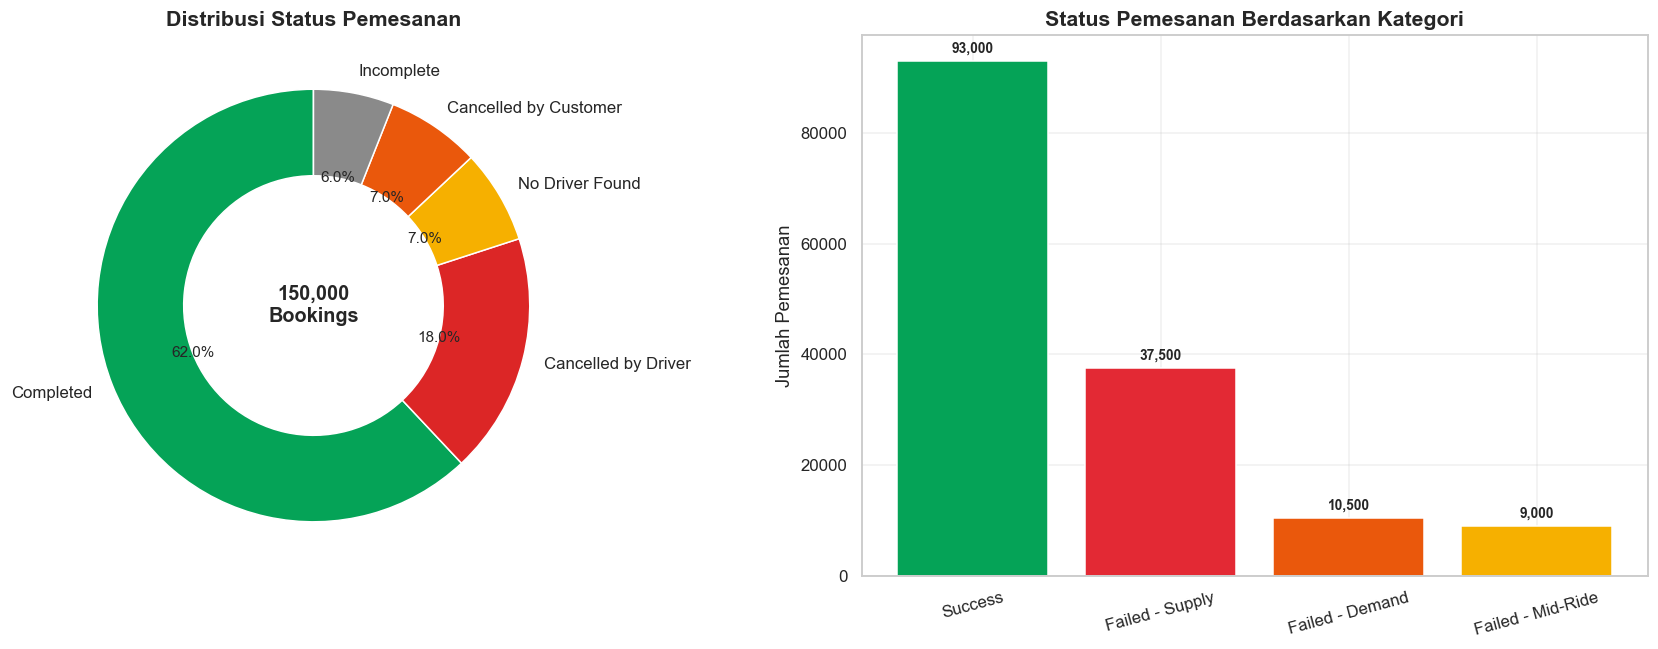

,Persentase (%)
Booking Status,
Completed,62.00
Cancelled by Driver,18.00
No Driver Found,7.00
Cancelled by Customer,7.00
Incomplete,6.00


In [12]:
# Distribusi status pemesanan
status_count = df["Booking Status"].value_counts()
status_percentage = (
    df["Booking Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Donut chart
status_colors = {
    "Completed": COLORS["success"],
    "Cancelled by Driver": COLORS["driver"],
    "Cancelled by Customer": COLORS["customer"],
    "No Driver Found": COLORS["warning"],
    "Incomplete": COLORS["neutral"],
}

axes[0].pie(
    status_count,
    labels=status_count.index,
    colors=[status_colors[s] for s in status_count.index],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4, "edgecolor": "white"},
)

axes[0].text(
    0, 0,
    f"{len(df):,}\nBookings",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
)

axes[0].set_title("Distribusi Status Pemesanan")

# Bar chart
category_count = df["StatusCategory"].value_counts()

category_colors = {
    "Success": COLORS["success"],
    "Failed - Supply": COLORS["danger"],
    "Failed - Demand": COLORS["customer"],
    "Failed - Mid-Ride": COLORS["warning"],
}

axes[1].bar(
    category_count.index,
    category_count.values,
    color=[category_colors[c] for c in category_count.index],
)

annotate_barv(axes[1])

axes[1].set_title("Status Pemesanan Berdasarkan Kategori")
axes[1].set_ylabel("Jumlah Pemesanan")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Ringkasan persentase status
status_percentage.to_frame("Persentase (%)")

### 8.2 Analisis Univariat — Distribusi Variabel Kunci

Analisis ini bertujuan untuk memahami distribusi variabel utama, baik kategorikal maupun numerik, seperti **jenis kendaraan, metode pembayaran, nilai pemesanan,** dan **jarak perjalanan**, sehingga memberikan gambaran awal mengenai karakteristik operasional bisnis.

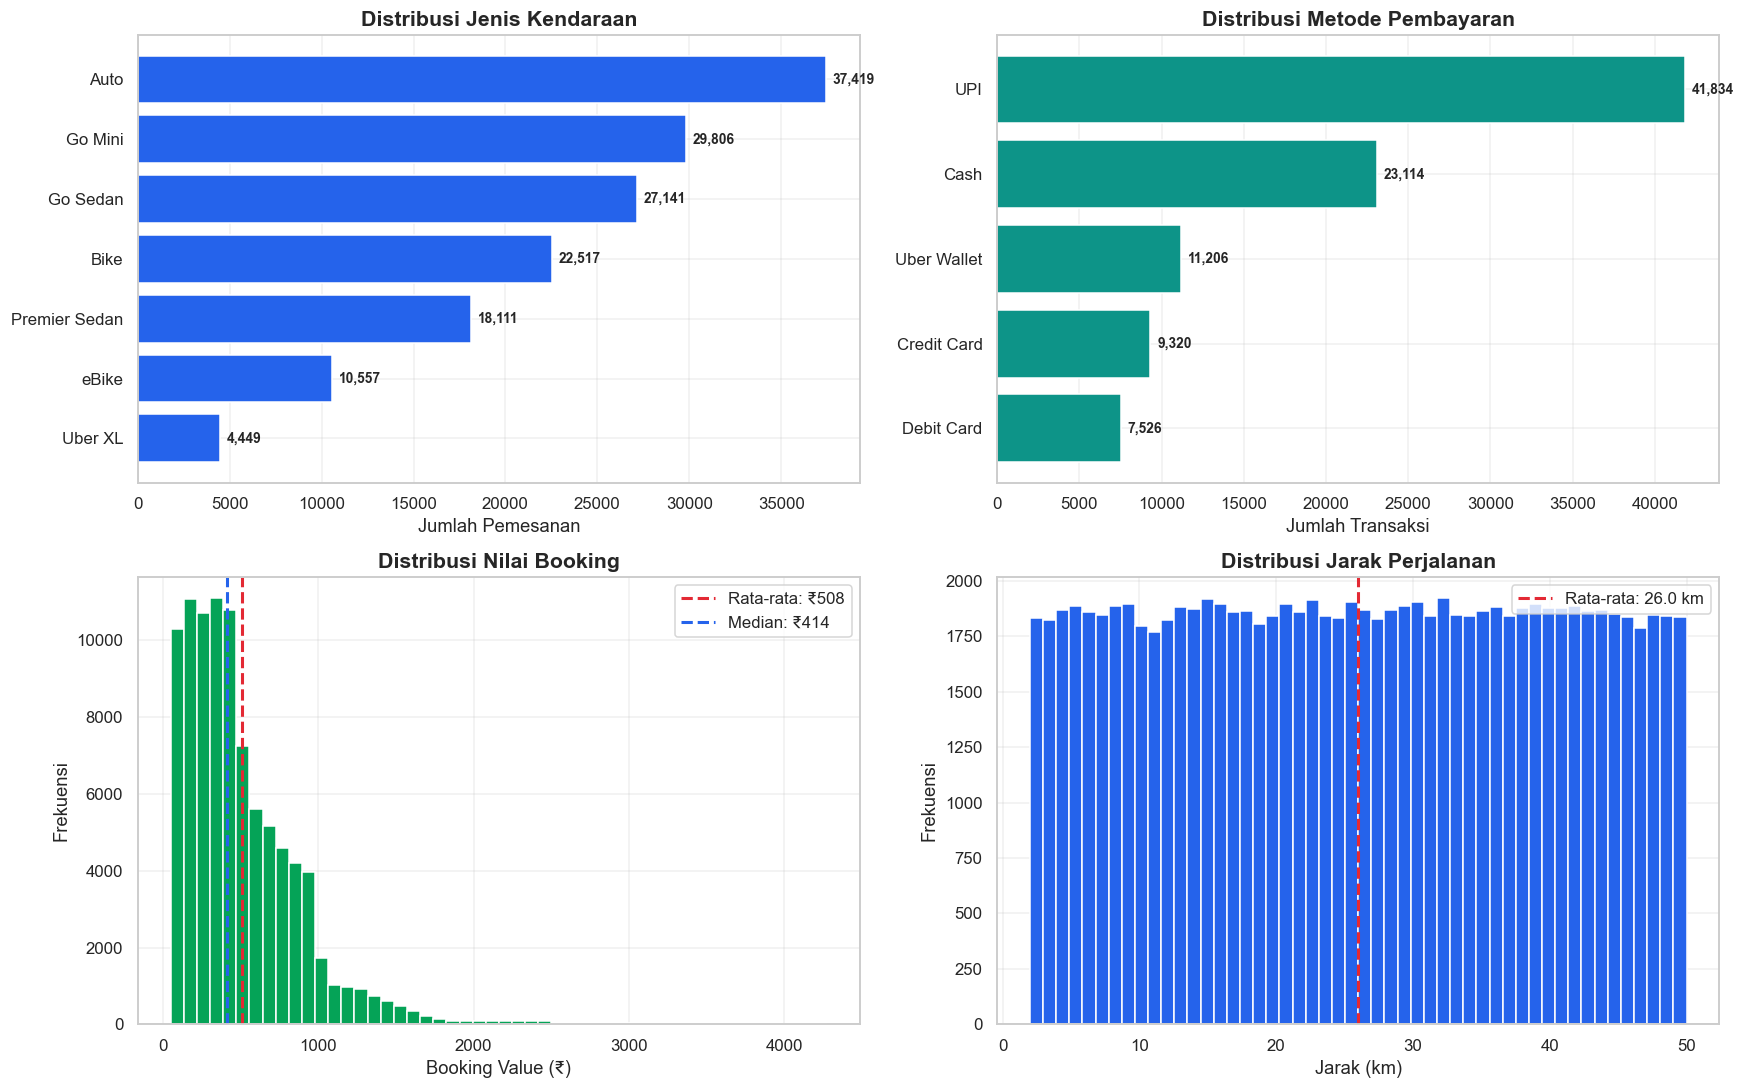

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribusi jenis kendaraan
vehicle_count = df["Vehicle Type"].value_counts()
axes[0, 0].barh(
    vehicle_count.index[::-1],
    vehicle_count.values[::-1],
    color=COLORS["primary"],
)
annotate_barh(axes[0, 0], vehicle_count.values[::-1])
axes[0, 0].set_title("Distribusi Jenis Kendaraan")
axes[0, 0].set_xlabel("Jumlah Pemesanan")

# Distribusi metode pembayaran
payment_count = completed["Payment Method"].value_counts()
axes[0, 1].barh(
    payment_count.index[::-1],
    payment_count.values[::-1],
    color=COLORS["teal"],
)
annotate_barh(axes[0, 1], payment_count.values[::-1])
axes[0, 1].set_title("Distribusi Metode Pembayaran")
axes[0, 1].set_xlabel("Jumlah Transaksi")

# Distribusi nilai booking
axes[1, 0].hist(
    completed["Booking Value"],
    bins=50,
    color=COLORS["success"],
    edgecolor="white",
)
axes[1, 0].axvline(
    completed["Booking Value"].mean(),
    color=COLORS["danger"],
    linestyle="--",
    linewidth=2,
    label=f"Rata-rata: ₹{completed['Booking Value'].mean():,.0f}",
)
axes[1, 0].axvline(
    completed["Booking Value"].median(),
    color=COLORS["primary"],
    linestyle="--",
    linewidth=2,
    label=f"Median: ₹{completed['Booking Value'].median():,.0f}",
)
axes[1, 0].set_title("Distribusi Nilai Booking")
axes[1, 0].set_xlabel("Booking Value (₹)")
axes[1, 0].set_ylabel("Frekuensi")
axes[1, 0].legend()

# Distribusi jarak perjalanan
axes[1, 1].hist(
    completed["Ride Distance"],
    bins=50,
    color=COLORS["primary"],
    edgecolor="white",
)
axes[1, 1].axvline(
    completed["Ride Distance"].mean(),
    color=COLORS["danger"],
    linestyle="--",
    linewidth=2,
    label=f"Rata-rata: {completed['Ride Distance'].mean():.1f} km",
)
axes[1, 1].set_title("Distribusi Jarak Perjalanan")
axes[1, 1].set_xlabel("Jarak (km)")
axes[1, 1].set_ylabel("Frekuensi")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 8.3 Analisis Bivariat — Pola Permintaan Temporal

Analisis ini mengevaluasi hubungan antara waktu pemesanan dan performa operasional berdasarkan **jam, hari,** serta **bagian hari**. Tujuannya adalah mengidentifikasi pola permintaan dan melihat perubahan **Booking Completion Rate** pada setiap periode waktu.

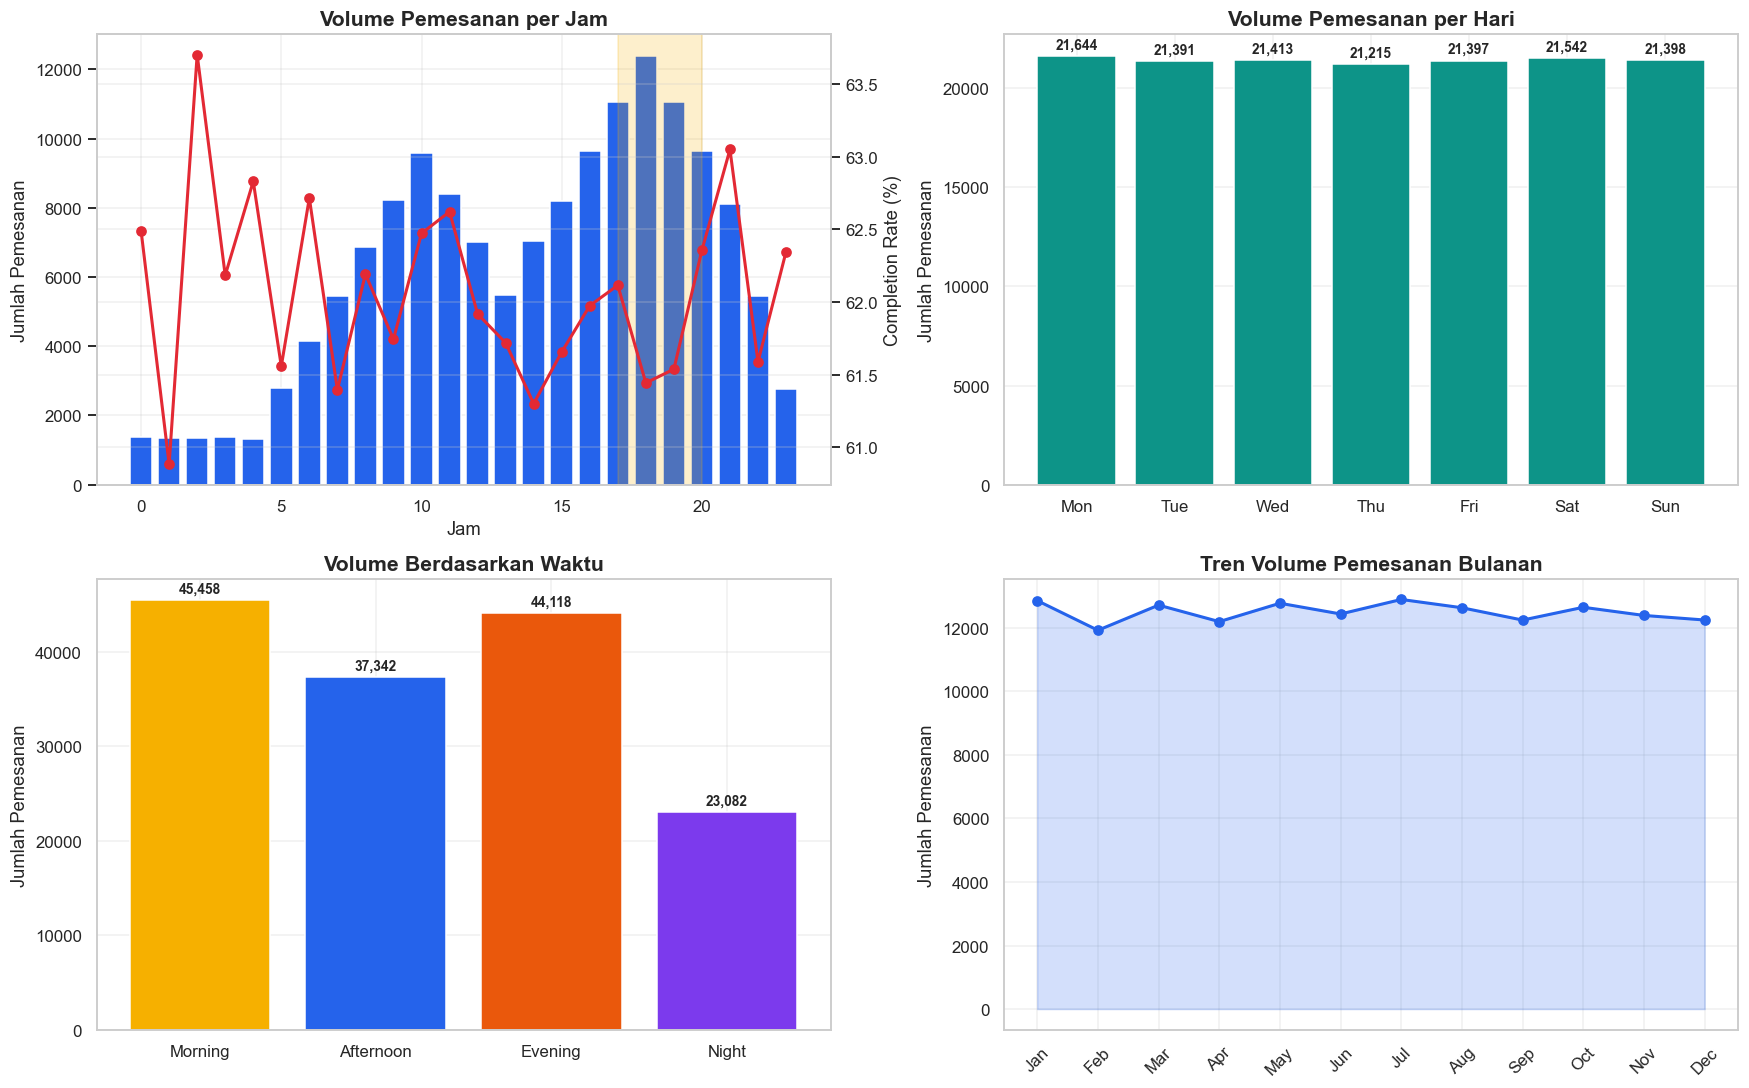

,Metrik,Nilai
0,Jam Tersibuk,18:00
1,Completion Rate Terendah,60.9%
2,Completion Rate Tertinggi,63.7%


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Volume pemesanan per jam
hourly = df.groupby("Hour").size()
completion_rate = df.groupby("Hour")["is_completed"].mean() * 100

axes[0, 0].bar(hourly.index, hourly.values, color=COLORS["primary"])
axes[0, 0].axvspan(17, 20, color=COLORS["warning"], alpha=0.2)
axes[0, 0].set_title("Volume Pemesanan per Jam")
axes[0, 0].set_xlabel("Jam")
axes[0, 0].set_ylabel("Jumlah Pemesanan")

ax2 = axes[0, 0].twinx()
ax2.plot(
    completion_rate.index,
    completion_rate.values,
    color=COLORS["danger"],
    marker="o",
    linewidth=2,
)
ax2.set_ylabel("Completion Rate (%)")

# Volume pemesanan per hari
day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

daily = df["Weekday"].value_counts().reindex(day_order)

axes[0, 1].bar(
    daily.index.str[:3],
    daily.values,
    color=COLORS["teal"],
)

annotate_barv(axes[0, 1])

axes[0, 1].set_title("Volume Pemesanan per Hari")
axes[0, 1].set_ylabel("Jumlah Pemesanan")

# Volume berdasarkan waktu
time_order = ["Morning", "Afternoon", "Evening", "Night"]

time_of_day = df["TimeOfDay"].value_counts().reindex(time_order)

axes[1, 0].bar(
    time_of_day.index,
    time_of_day.values,
    color=[
        COLORS["warning"],
        COLORS["primary"],
        COLORS["customer"],
        COLORS["purple"],
    ],
)

annotate_barv(axes[1, 0])

axes[1, 0].set_title("Volume Berdasarkan Waktu")
axes[1, 0].set_ylabel("Jumlah Pemesanan")

# Tren bulanan
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly = df["Month"].value_counts().reindex(month_order)

axes[1, 1].plot(
    monthly.index.str[:3],
    monthly.values,
    color=COLORS["primary"],
    marker="o",
    linewidth=2,
)

axes[1, 1].fill_between(
    monthly.index.str[:3],
    monthly.values,
    alpha=0.2,
    color=COLORS["primary"],
)

axes[1, 1].set_title("Tren Volume Pemesanan Bulanan")
axes[1, 1].set_ylabel("Jumlah Pemesanan")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Ringkasan
pd.DataFrame({
    "Metrik": [
        "Jam Tersibuk",
        "Completion Rate Terendah",
        "Completion Rate Tertinggi",
    ],
    "Nilai": [
        f"{hourly.idxmax()}:00",
        f"{completion_rate.min():.1f}%",
        f"{completion_rate.max():.1f}%",
    ],
})

### 8.4 Analisis Bivariat — Performa Jenis Kendaraan

Analisis ini membandingkan kinerja setiap **jenis kendaraan** berdasarkan **pendapatan, rata-rata tarif, Booking Completion Rate,** dan **pendapatan per kilometer** untuk mengidentifikasi segmen kendaraan yang memberikan kontribusi bisnis paling besar.

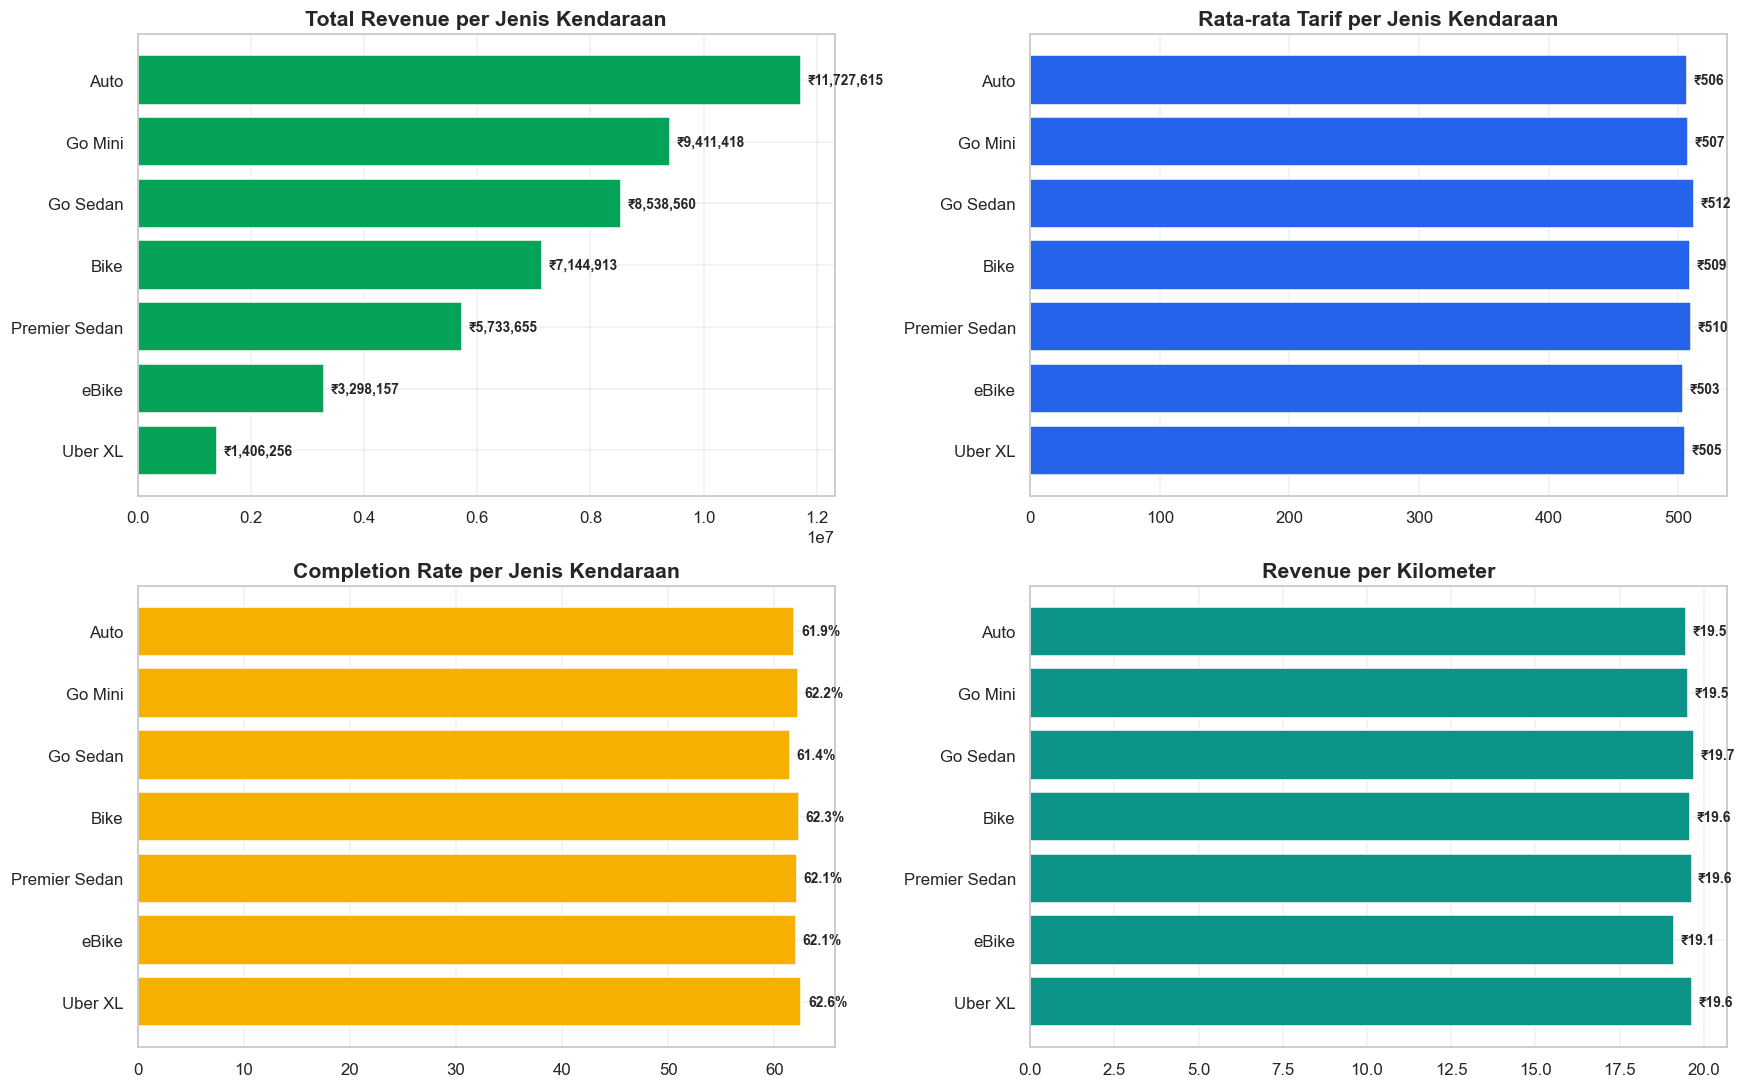

,Total_Revenue,Average_Fare,Average_Distance,Total_Rides,Completion_Rate,Revenue_Per_Km
Vehicle Type,,,,,,
Auto,"11,727,615.00",506.48,25.99,23155,61.88,19.49
Go Mini,"9,411,418.00",507.38,25.99,18549,62.23,19.52
Go Sedan,"8,538,560.00",512.03,25.98,16676,61.44,19.71
Bike,"7,144,913.00",509.11,26.00,14034,62.33,19.58
Premier Sedan,"5,733,655.00",509.57,25.95,11252,62.13,19.64
eBike,"3,298,157.00",503.46,26.34,6551,62.05,19.11
Uber XL,"1,406,256.00",505.30,25.72,2783,62.55,19.64


In [15]:
# Ringkasan performa setiap jenis kendaraan
vehicle_summary = completed.groupby("Vehicle Type").agg(
    Total_Revenue=("Booking Value", "sum"),
    Average_Fare=("Booking Value", "mean"),
    Average_Distance=("Ride Distance", "mean"),
    Total_Rides=("Booking ID", "count"),
)

vehicle_summary["Completion_Rate"] = (
    df.groupby("Vehicle Type")["is_completed"].mean() * 100
)

vehicle_summary["Revenue_Per_Km"] = (
    vehicle_summary["Total_Revenue"]
    / completed.groupby("Vehicle Type")["Ride Distance"].sum()
)

vehicle_summary = vehicle_summary.sort_values(
    "Total_Revenue",
    ascending=False,
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Total revenue
axes[0, 0].barh(
    vehicle_summary.index[::-1],
    vehicle_summary["Total_Revenue"][::-1],
    color=COLORS["success"],
)
annotate_barh(
    axes[0, 0],
    vehicle_summary["Total_Revenue"][::-1],
    fmt="₹{:,.0f}",
)
axes[0, 0].set_title("Total Revenue per Jenis Kendaraan")

# Rata-rata tarif
axes[0, 1].barh(
    vehicle_summary.index[::-1],
    vehicle_summary["Average_Fare"][::-1],
    color=COLORS["primary"],
)
annotate_barh(
    axes[0, 1],
    vehicle_summary["Average_Fare"][::-1],
    fmt="₹{:,.0f}",
)
axes[0, 1].set_title("Rata-rata Tarif per Jenis Kendaraan")

# Completion rate
axes[1, 0].barh(
    vehicle_summary.index[::-1],
    vehicle_summary["Completion_Rate"][::-1],
    color=COLORS["warning"],
)
annotate_barh(
    axes[1, 0],
    vehicle_summary["Completion_Rate"][::-1],
    fmt="{:.1f}%",
)
axes[1, 0].set_title("Completion Rate per Jenis Kendaraan")

# Revenue per km
axes[1, 1].barh(
    vehicle_summary.index[::-1],
    vehicle_summary["Revenue_Per_Km"][::-1],
    color=COLORS["teal"],
)
annotate_barh(
    axes[1, 1],
    vehicle_summary["Revenue_Per_Km"][::-1],
    fmt="₹{:.1f}",
)
axes[1, 1].set_title("Revenue per Kilometer")

plt.tight_layout()
plt.show()

vehicle_summary.round(2)

### 8.5 Analisis Bivariat — Lokasi & Rute Perjalanan

Analisis ini mengevaluasi pola permintaan berdasarkan **lokasi penjemputan, lokasi tujuan,** dan **rute perjalanan** untuk mengidentifikasi area dengan aktivitas pemesanan tertinggi serta mendukung optimalisasi alokasi pengemudi.

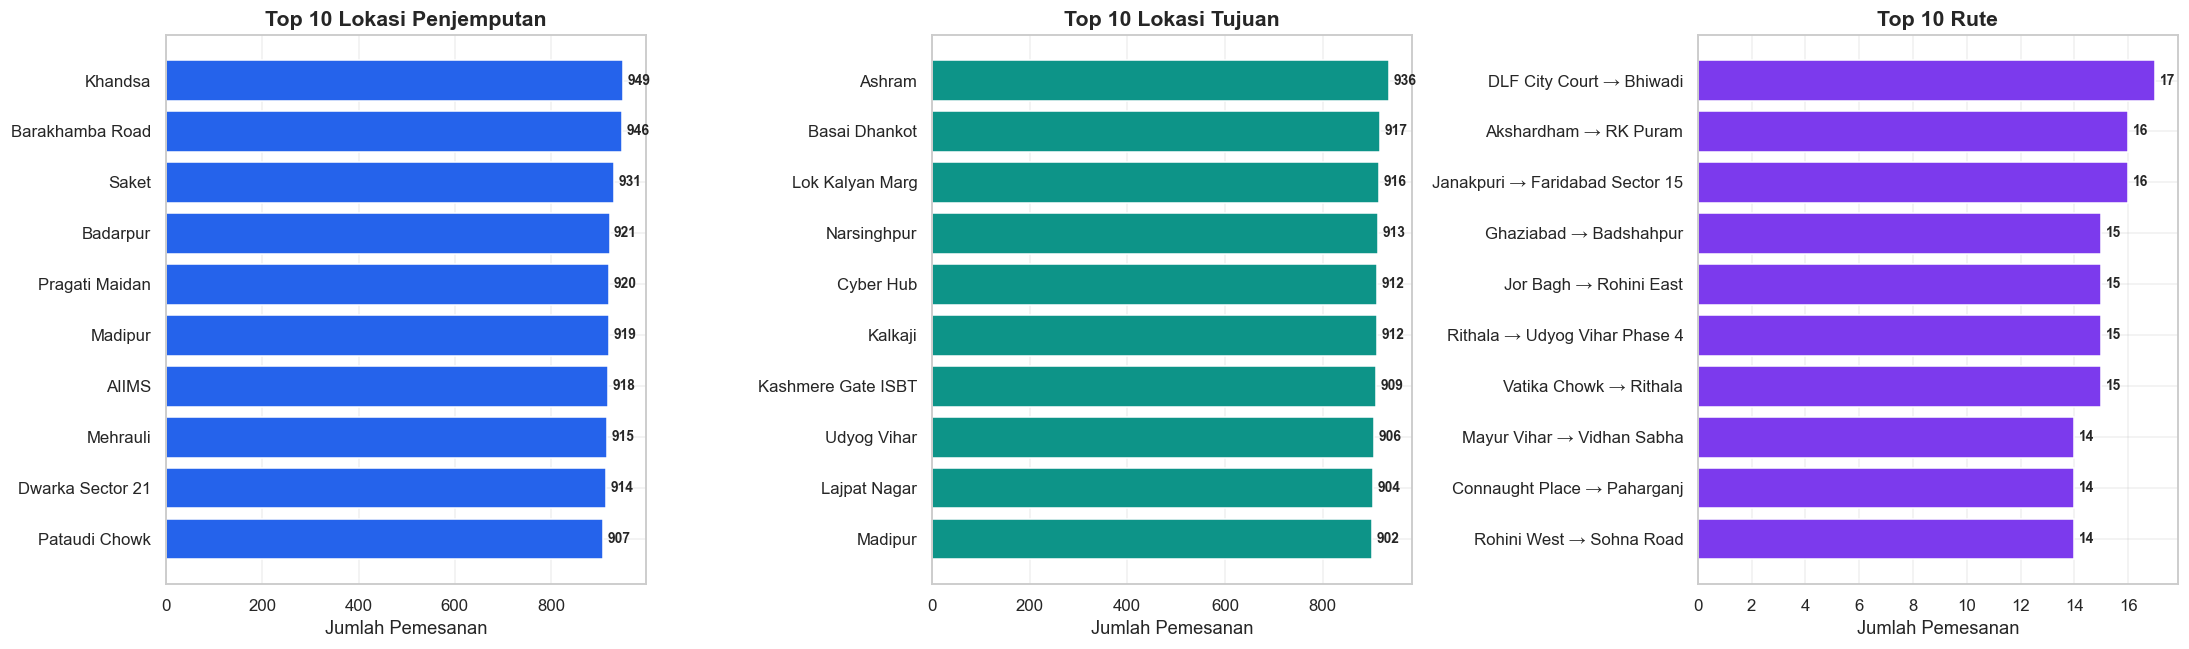

,Metrik,Nilai
0,Jumlah Perjalanan pada Rute Terpadat,17
1,Jumlah Rute Unik,30564


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Top 10 lokasi penjemputan
pickup_count = df["Pickup Location"].value_counts().head(10)

axes[0].barh(
    pickup_count.index[::-1],
    pickup_count.values[::-1],
    color=COLORS["primary"],
)

annotate_barh(axes[0], pickup_count.values[::-1])

axes[0].set_title("Top 10 Lokasi Penjemputan")
axes[0].set_xlabel("Jumlah Pemesanan")

# Top 10 lokasi tujuan
dropoff_count = df["Drop Location"].value_counts().head(10)

axes[1].barh(
    dropoff_count.index[::-1],
    dropoff_count.values[::-1],
    color=COLORS["teal"],
)

annotate_barh(axes[1], dropoff_count.values[::-1])

axes[1].set_title("Top 10 Lokasi Tujuan")
axes[1].set_xlabel("Jumlah Pemesanan")

# Top 10 rute
route_count = df["Route"].value_counts().head(10)

axes[2].barh(
    route_count.index[::-1],
    route_count.values[::-1],
    color=COLORS["purple"],
)

annotate_barh(axes[2], route_count.values[::-1])

axes[2].set_title("Top 10 Rute")
axes[2].set_xlabel("Jumlah Pemesanan")

plt.tight_layout()
plt.show()

# Ringkasan
pd.DataFrame({
    "Metrik": [
        "Jumlah Perjalanan pada Rute Terpadat",
        "Jumlah Rute Unik",
    ],
    "Nilai": [
        route_count.max(),
        df["Route"].nunique(),
    ],
})

# 9. Cancellation & Revenue Leakage Analysis

Pembatalan dan kegagalan pemesanan dianalisis untuk mengukur besarnya **revenue leakage** serta mengidentifikasi faktor-faktor yang menyebabkan permintaan tidak berhasil dikonversi menjadi perjalanan yang selesai.

---

### 9.1 Analisis Penyebab Pembatalan

Analisis ini bertujuan untuk mengidentifikasi penyebab utama pembatalan dari sisi **pelanggan** maupun **pengemudi**, sehingga dapat menjadi dasar dalam menentukan strategi untuk meningkatkan **Booking Completion Rate** dan mengurangi *revenue leakage*.

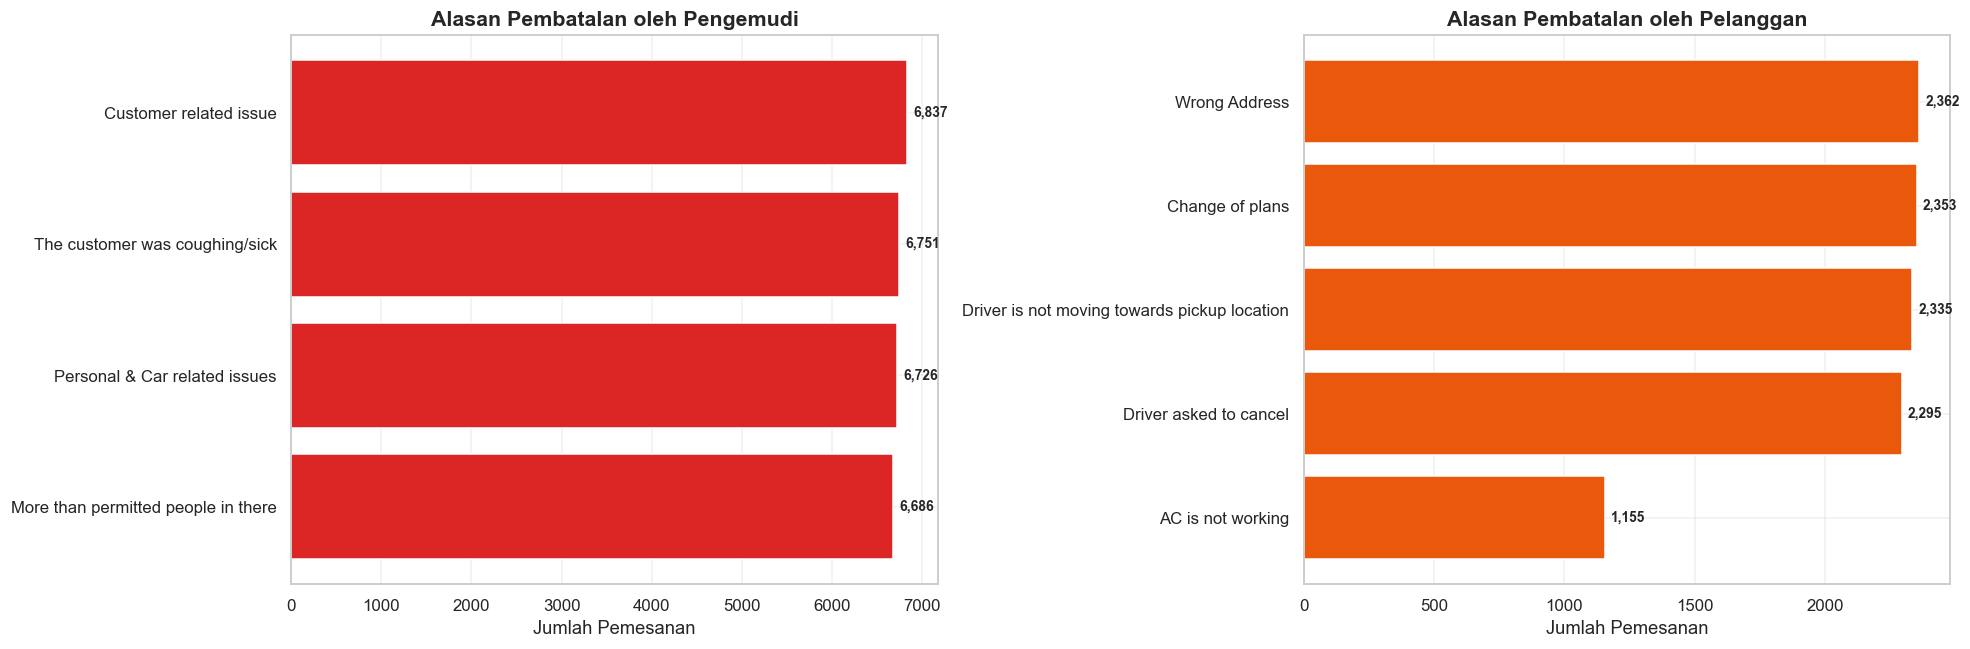

,Alasan,Jumlah
0,Customer Demand,3040
1,Vehicle Breakdown,3012
2,Other Issue,2948


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Alasan pembatalan oleh pengemudi
driver_reason = df["Driver Cancellation Reason"].value_counts()

axes[0].barh(
    driver_reason.index[::-1],
    driver_reason.values[::-1],
    color=COLORS["driver"],
)

annotate_barh(axes[0], driver_reason.values[::-1])

axes[0].set_title("Alasan Pembatalan oleh Pengemudi")
axes[0].set_xlabel("Jumlah Pemesanan")

# Alasan pembatalan oleh pelanggan
customer_reason = df["Reason for cancelling by Customer"].value_counts()

axes[1].barh(
    customer_reason.index[::-1],
    customer_reason.values[::-1],
    color=COLORS["customer"],
)

annotate_barh(axes[1], customer_reason.values[::-1])

axes[1].set_title("Alasan Pembatalan oleh Pelanggan")
axes[1].set_xlabel("Jumlah Pemesanan")

plt.tight_layout()
plt.show()

# Alasan perjalanan tidak selesai
df["Incomplete Rides Reason"].value_counts().rename_axis(
    "Alasan"
).reset_index(name="Jumlah")

In [18]:
# Analisis potensi revenue leakage
average_fare = completed["Booking Value"].mean()
failed_bookings = len(df) - len(completed)
estimated_leakage = failed_bookings * average_fare

summary = pd.DataFrame({
    "Metrik": [
        "Rata-rata Nilai Booking",
        "Jumlah Booking Gagal",
        "Estimasi Revenue Leakage",
        "Potensi Recovery (20%)",
        "Potensi Recovery (50%)",
        "Nilai Tambahan per +1% Completion Rate",
    ],
    "Nilai": [
        f"₹{average_fare:,.0f}",
        f"{failed_bookings:,}",
        f"₹{estimated_leakage:,.0f}",
        f"₹{estimated_leakage * 0.20:,.0f}",
        f"₹{estimated_leakage * 0.50:,.0f}",
        f"₹{len(df) * 0.01 * average_fare:,.0f}",
    ],
})

summary

,Metrik,Nilai
0,Rata-rata Nilai Booking,₹508
1,Jumlah Booking Gagal,"57,000"
2,Estimasi Revenue Leakage,"₹28,966,158"
3,Potensi Recovery (20%),"₹5,793,232"
4,Potensi Recovery (50%),"₹14,483,079"
5,Nilai Tambahan per +1% Completion Rate,"₹762,267"


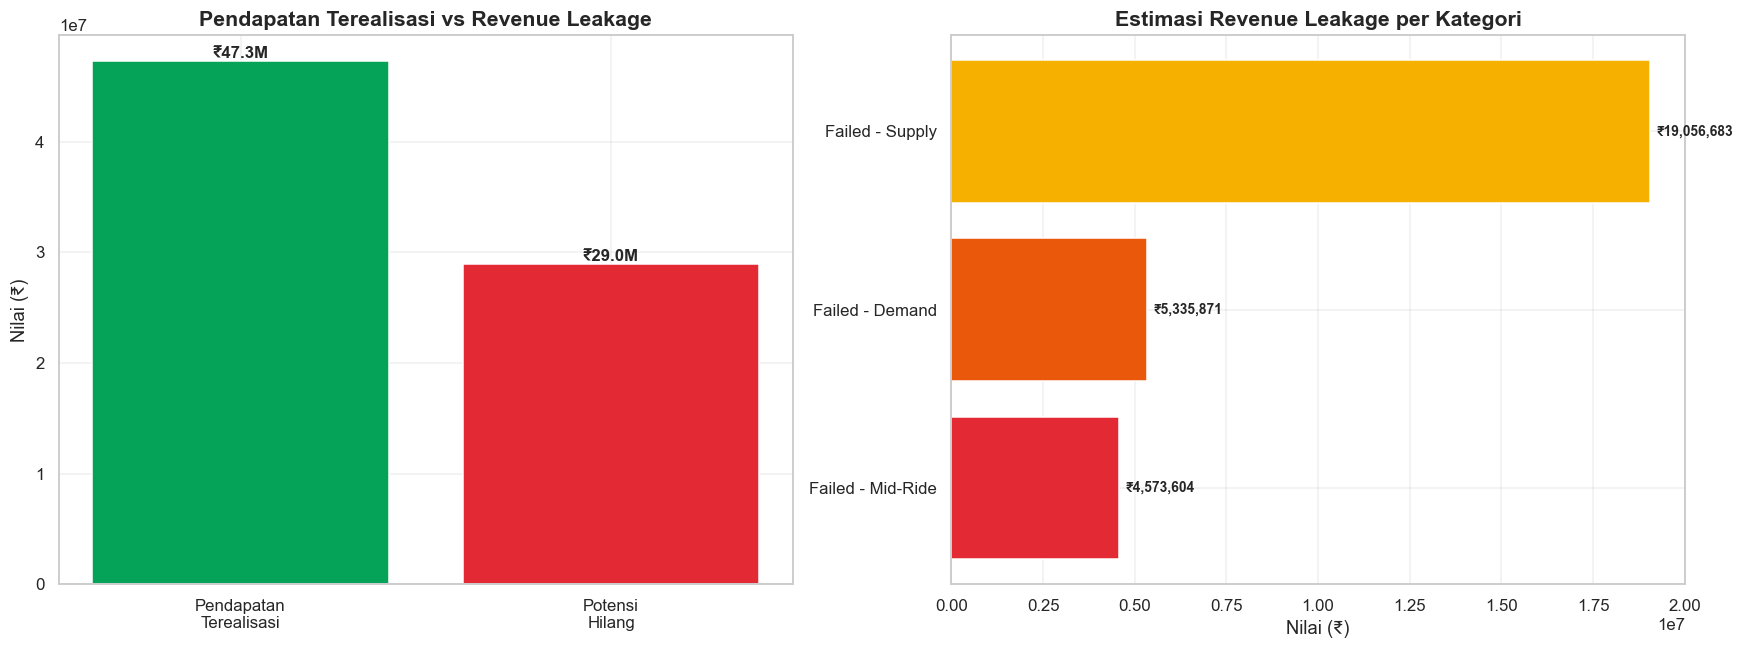

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pendapatan terealisasi vs potensi hilang
realized_revenue = completed["Booking Value"].sum()

axes[0].bar(
    ["Pendapatan\nTerealisasi", "Potensi\nHilang"],
    [realized_revenue, estimated_leakage],
    color=[COLORS["success"], COLORS["danger"]],
)

for i, value in enumerate([realized_revenue, estimated_leakage]):
    axes[0].text(
        i,
        value,
        f"₹{value/1e6:.1f}M",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

axes[0].set_title("Pendapatan Terealisasi vs Revenue Leakage")
axes[0].set_ylabel("Nilai (₹)")

# Estimasi revenue leakage berdasarkan penyebab
leakage_by_status = (
    df.loc[~df["is_completed"], "StatusCategory"]
      .value_counts()
      .mul(average_fare)
)

axes[1].barh(
    leakage_by_status.index[::-1],
    leakage_by_status.values[::-1],
    color=[
        COLORS["warning"],
        COLORS["customer"],
        COLORS["danger"],
    ][::-1],
)

annotate_barh(
    axes[1],
    leakage_by_status.values[::-1],
    fmt="₹{:,.0f}",
)

axes[1].set_title("Estimasi Revenue Leakage per Kategori")
axes[1].set_xlabel("Nilai (₹)")

plt.tight_layout()
plt.show()

# 11. Customer Segmentation Analysis

Analisis ini bertujuan untuk mengelompokkan pelanggan berdasarkan karakteristik dan perilaku pemesanannya. Segmentasi digunakan untuk mengidentifikasi kelompok pelanggan yang memiliki pola penggunaan serupa sehingga dapat mendukung strategi pemasaran, retensi, dan personalisasi layanan.

### 11.2 Segmentasi Perjalanan — K-Means Clustering

Analisis ini menggunakan **K-Means Clustering** untuk mengelompokkan perjalanan berdasarkan karakteristik operasional dan finansial. Proses segmentasi dilakukan menggunakan fitur **Booking Value**, **Ride Distance**, **PricePerKm**, dan **Avg VTAT** yang telah distandarisasi. Jumlah cluster optimal ditentukan menggunakan **Elbow Method** dan **Silhouette Score**.

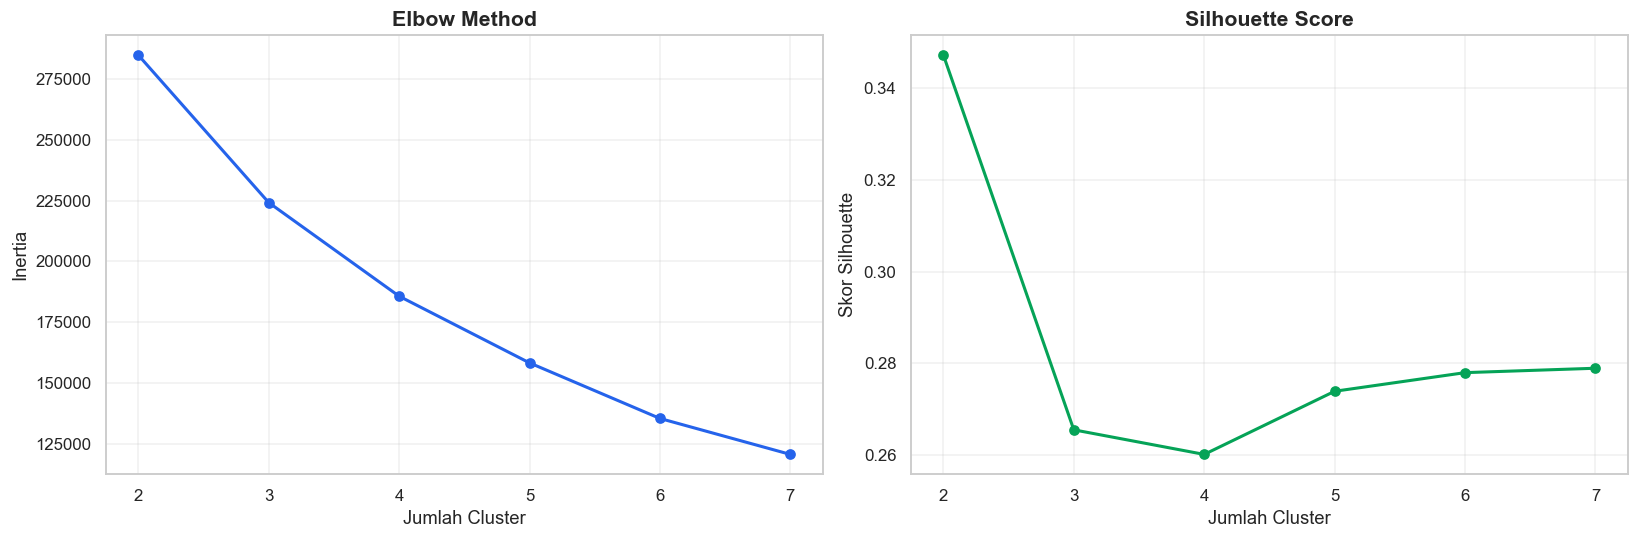

,Jumlah Cluster Optimal,Silhouette Score
0,2,0.35


In [21]:
# Data completed terbaru
completed = df[df["Booking Status"] == "Completed"].copy()

# Menyiapkan data untuk clustering
cluster_features = ["Booking Value", "Ride Distance", "PricePerKm", "Avg VTAT"]
cluster_data = completed[cluster_features].dropna()

# Standarisasi data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# Evaluasi jumlah cluster
k_values = range(2, 8)
inertia = []
silhouette = []

sample_index = np.random.default_rng(42).choice(
    len(scaled_data), size=min(10000, len(scaled_data)), replace=False
)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_data)

    inertia.append(model.inertia_)
    silhouette.append(
        silhouette_score(scaled_data[sample_index], labels[sample_index])
    )

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(k_values, inertia, marker="o", linewidth=2, color=COLORS["primary"])
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Jumlah Cluster")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_values, silhouette, marker="o", linewidth=2, color=COLORS["success"])
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Jumlah Cluster")
axes[1].set_ylabel("Skor Silhouette")

plt.tight_layout()
plt.show()

# Ringkasan
optimal_k = k_values[np.argmax(silhouette)]

pd.DataFrame({
    "Jumlah Cluster Optimal": [optimal_k],
    "Silhouette Score": [max(silhouette)],
}).round(3)

In [22]:
# Membentuk model K-Means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_data["Cluster"] = kmeans.fit_predict(scaled_data)

# Profil setiap cluster
cluster_profile = (
    cluster_data
    .groupby("Cluster")
    .agg(
        Total_Trips=("Booking Value", "size"),
        Average_Fare=("Booking Value", "mean"),
        Average_Distance=("Ride Distance", "mean"),
        Average_Price_Per_Km=("PricePerKm", "mean"),
        Average_VTAT=("Avg VTAT", "mean"),
    )
    .round(2)
)

cluster_profile["Share (%)"] = (
    cluster_profile["Total_Trips"]
    / cluster_profile["Total_Trips"].sum()
    * 100
).round(1)

cluster_profile

,Total_Trips,Average_Fare,Average_Distance,Average_Price_Per_Km,Average_VTAT,Share (%)
Cluster,,,,,,
0,17579,933.99,12.24,108.07,8.46,18.90
1,75421,408.93,29.21,16.56,8.52,81.10


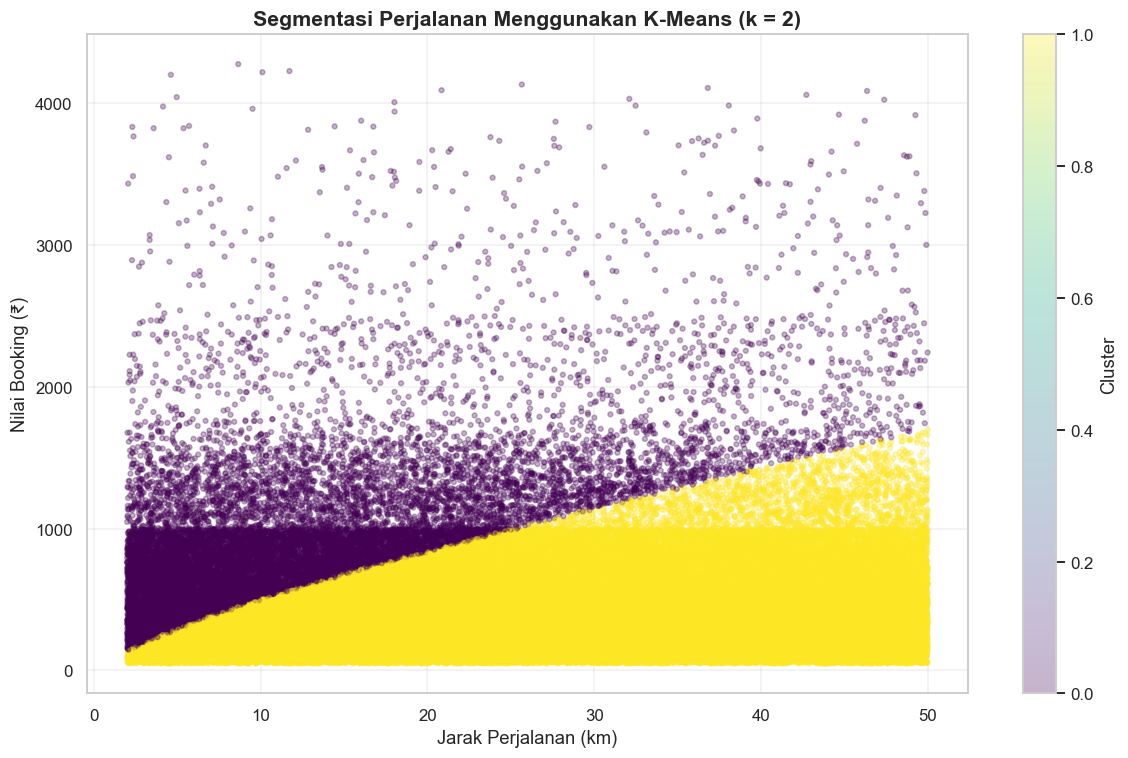

In [23]:
# Visualisasi hasil clustering
fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    cluster_data["Ride Distance"],
    cluster_data["Booking Value"],
    c=cluster_data["Cluster"],
    cmap="viridis",
    alpha=0.3,
    s=10,
)

ax.set_title(f"Segmentasi Perjalanan Menggunakan K-Means (k = {optimal_k})")
ax.set_xlabel("Jarak Perjalanan (km)")
ax.set_ylabel("Nilai Booking (₹)")

plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

# 12. Business Insights

Pada bagian ini, berbagai **business insight** diperoleh melalui analisis terhadap data yang telah dibersihkan dan dimodelkan. Analisis difokuskan pada identifikasi pola, peringkat, serta metrik bisnis utama yang dapat mendukung pengambilan keputusan operasional dan strategis.

Insight yang dihasilkan mencakup performa pemesanan, kontribusi pendapatan, perilaku pelanggan, distribusi permintaan, analisis pembatalan, serta berbagai peringkat (*ranking*) berdasarkan dimensi bisnis seperti jenis kendaraan, metode pembayaran, lokasi, dan waktu.

---

### 12.1 Ringkasan Metrik Bisnis

Bagian ini menyajikan metrik bisnis utama sebagai gambaran umum performa platform, seperti total pemesanan, tingkat penyelesaian perjalanan, pendapatan, rata-rata nilai pemesanan, dan indikator operasional lainnya sebelum dilakukan analisis yang lebih mendalam.

In [24]:
# Menyimpan data ke SQLite
db_path = "analysis_database.db"
connection = sqlite3.connect(db_path)

sql_data = df.copy()
sql_data.columns = sql_data.columns.str.replace(" ", "_")
sql_data["Datetime"] = sql_data["Datetime"].dt.strftime("%Y-%m-%d %H:%M:%S")

sql_data.to_sql(
    "bookings",
    connection,
    if_exists="replace",
    index=False,
)

# Menjalankan query SQL
def run_query(query):
    result = pd.read_sql_query(query, connection)
    display(result)
    return result

# Ringkasan data
run_query("""
SELECT
    COUNT(*) AS Total_Baris,
    COUNT(DISTINCT Customer_ID) AS Total_Pelanggan
FROM bookings;
""")

,Total_Baris,Total_Pelanggan
0,150000,148788


,Total_Baris,Total_Pelanggan
0,150000,148788


In [25]:
# Status Pemesanan Terbanyak
run_query("""
SELECT
    Booking_Status,
    COUNT(*) AS total_bookings,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM bookings),2) AS percentage
FROM bookings
GROUP BY Booking_Status
ORDER BY total_bookings DESC;
""")

,Booking_Status,total_bookings,percentage
0,Completed,93000,62.00
1,Cancelled by Driver,27000,18.00
2,No Driver Found,10500,7.00
3,Cancelled by Customer,10500,7.00
4,Incomplete,9000,6.00


,Booking_Status,total_bookings,percentage
0,Completed,93000,62.00
1,Cancelled by Driver,27000,18.00
2,No Driver Found,10500,7.00
3,Cancelled by Customer,10500,7.00
4,Incomplete,9000,6.00


In [26]:
# Jenis Kendaraan dengan Pendapatan Tertinggi
run_query("""
SELECT
    Vehicle_Type,
    COUNT(*) AS completed_trips,
    ROUND(SUM(Booking_Value),0) AS total_revenue,
    ROUND(AVG(Booking_Value),2) AS average_fare
FROM bookings
WHERE Booking_Status='Completed'
GROUP BY Vehicle_Type
ORDER BY total_revenue DESC;
""")

,Vehicle_Type,completed_trips,total_revenue,average_fare
0,Auto,23155,"11,727,615.00",506.48
1,Go Mini,18549,"9,411,418.00",507.38
2,Go Sedan,16676,"8,538,560.00",512.03
3,Bike,14034,"7,144,913.00",509.11
4,Premier Sedan,11252,"5,733,655.00",509.57
5,eBike,6551,"3,298,157.00",503.46
6,Uber XL,2783,"1,406,256.00",505.30


,Vehicle_Type,completed_trips,total_revenue,average_fare
0,Auto,23155,"11,727,615.00",506.48
1,Go Mini,18549,"9,411,418.00",507.38
2,Go Sedan,16676,"8,538,560.00",512.03
3,Bike,14034,"7,144,913.00",509.11
4,Premier Sedan,11252,"5,733,655.00",509.57
5,eBike,6551,"3,298,157.00",503.46
6,Uber XL,2783,"1,406,256.00",505.30


In [27]:
# Metode Pembayaran Paling Banyak Digunakan
run_query("""
SELECT
    Payment_Method,
    COUNT(*) AS total_transactions,
    ROUND(SUM(Booking_Value),0) AS total_revenue
FROM bookings
WHERE Booking_Status='Completed'
GROUP BY Payment_Method
ORDER BY total_transactions DESC;
""")

,Payment_Method,total_transactions,total_revenue
0,UPI,41834,"21,274,591.00"
1,Cash,23114,"11,756,071.00"
2,Uber Wallet,11206,"5,669,070.00"
3,Credit Card,9320,"4,753,767.00"
4,Debit Card,7526,"3,807,075.00"


,Payment_Method,total_transactions,total_revenue
0,UPI,41834,"21,274,591.00"
1,Cash,23114,"11,756,071.00"
2,Uber Wallet,11206,"5,669,070.00"
3,Credit Card,9320,"4,753,767.00"
4,Debit Card,7526,"3,807,075.00"


In [28]:
# Lokasi Penjemputan dengan Permintaan Tertinggi
run_query("""
SELECT
    Pickup_Location,
    COUNT(*) AS total_bookings
FROM bookings
GROUP BY Pickup_Location
ORDER BY total_bookings DESC
LIMIT 10;
""")

,Pickup_Location,total_bookings
0,Khandsa,949
1,Barakhamba Road,946
2,Saket,931
3,Badarpur,921
4,Pragati Maidan,920
5,Madipur,919
6,AIIMS,918
7,Mehrauli,915
8,Dwarka Sector 21,914
9,Pataudi Chowk,907


,Pickup_Location,total_bookings
0,Khandsa,949
1,Barakhamba Road,946
2,Saket,931
3,Badarpur,921
4,Pragati Maidan,920
5,Madipur,919
6,AIIMS,918
7,Mehrauli,915
8,Dwarka Sector 21,914
9,Pataudi Chowk,907


In [29]:
# Lokasi Tujuan Terpopuler
run_query("""
SELECT
    Drop_Location,
    COUNT(*) AS total_bookings
FROM bookings
GROUP BY Drop_Location
ORDER BY total_bookings DESC
LIMIT 10;
""")

,Drop_Location,total_bookings
0,Ashram,936
1,Basai Dhankot,917
2,Lok Kalyan Marg,916
3,Narsinghpur,913
4,Kalkaji,912
5,Cyber Hub,912
6,Kashmere Gate ISBT,909
7,Udyog Vihar,906
8,Lajpat Nagar,904
9,Nehru Place,902


,Drop_Location,total_bookings
0,Ashram,936
1,Basai Dhankot,917
2,Lok Kalyan Marg,916
3,Narsinghpur,913
4,Kalkaji,912
5,Cyber Hub,912
6,Kashmere Gate ISBT,909
7,Udyog Vihar,906
8,Lajpat Nagar,904
9,Nehru Place,902


In [30]:
# Rute Perjalanan Tersibuk
run_query("""
SELECT
    Pickup_Location || ' → ' || Drop_Location AS route,
    COUNT(*) AS total_trips,
    ROUND(AVG(Booking_Value),2) AS average_fare
FROM bookings
WHERE Booking_Status='Completed'
GROUP BY route
ORDER BY total_trips DESC
LIMIT 10;
""")

,route,total_trips,average_fare
0,Rohini West → Sohna Road,13,477.23
1,DLF City Court → Bhiwadi,13,455.77
2,Sushant Lok → Sarai Kale Khan,11,511.82
3,Subhash Chowk → IGNOU Road,11,469.09
4,Rithala → Udyog Vihar Phase 4,11,575.00
5,Noida Sector 62 → Sarai Kale Khan,11,465.82
6,Lok Kalyan Marg → Jhilmil,11,410.91
7,Ambience Mall → Akshardham,11,774.36
8,Vishwavidyalaya → Yamuna Bank,10,304.70
9,Vasant Kunj → Vidhan Sabha,10,406.00


,route,total_trips,average_fare
0,Rohini West → Sohna Road,13,477.23
1,DLF City Court → Bhiwadi,13,455.77
2,Sushant Lok → Sarai Kale Khan,11,511.82
3,Subhash Chowk → IGNOU Road,11,469.09
4,Rithala → Udyog Vihar Phase 4,11,575.00
5,Noida Sector 62 → Sarai Kale Khan,11,465.82
6,Lok Kalyan Marg → Jhilmil,11,410.91
7,Ambience Mall → Akshardham,11,774.36
8,Vishwavidyalaya → Yamuna Bank,10,304.70
9,Vasant Kunj → Vidhan Sabha,10,406.00


In [31]:
# Jam dengan Permintaan Tertinggi
run_query("""
SELECT
    CAST(strftime('%H', Datetime) AS INTEGER) AS hour,
    COUNT(*) AS total_bookings,
    ROUND(
        100.0 * SUM(CASE WHEN Booking_Status='Completed' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS completion_rate
FROM bookings
GROUP BY hour
ORDER BY total_bookings DESC;
""")

,hour,total_bookings,completion_rate
0,18,12397,61.44
1,19,11047,61.54
2,17,11044,62.12
3,16,9633,61.97
4,20,9630,62.36
5,10,9577,62.47
6,11,8390,62.62
7,9,8234,61.74
8,15,8202,61.66
9,21,8103,63.05


,hour,total_bookings,completion_rate
0,18,12397,61.44
1,19,11047,61.54
2,17,11044,62.12
3,16,9633,61.97
4,20,9630,62.36
5,10,9577,62.47
6,11,8390,62.62
7,9,8234,61.74
8,15,8202,61.66
9,21,8103,63.05


In [32]:
# Hari dengan Aktivitas Tertinggi
run_query("""
SELECT
    CASE CAST(strftime('%w', Datetime) AS INTEGER)
        WHEN 0 THEN 'Sunday'
        WHEN 1 THEN 'Monday'
        WHEN 2 THEN 'Tuesday'
        WHEN 3 THEN 'Wednesday'
        WHEN 4 THEN 'Thursday'
        WHEN 5 THEN 'Friday'
        WHEN 6 THEN 'Saturday'
    END AS weekday,
    COUNT(*) AS total_bookings
FROM bookings
GROUP BY weekday
ORDER BY total_bookings DESC;
""")

,weekday,total_bookings
0,Monday,21644
1,Saturday,21542
2,Wednesday,21413
3,Sunday,21398
4,Friday,21397
5,Tuesday,21391
6,Thursday,21215


,weekday,total_bookings
0,Monday,21644
1,Saturday,21542
2,Wednesday,21413
3,Sunday,21398
4,Friday,21397
5,Tuesday,21391
6,Thursday,21215


In [33]:
# Tren Permintaan Bulanan
run_query("""
SELECT
    strftime('%Y-%m', Datetime) AS month,
    COUNT(*) AS total_bookings,
    ROUND(SUM(Booking_Value),0) AS total_revenue
FROM bookings
WHERE Booking_Status='Completed'
GROUP BY month
ORDER BY month;
""")

,month,total_bookings,total_revenue
0,2024-01,7951,"4,001,547.00"
1,2024-02,7368,"3,756,610.00"
2,2024-03,7954,"4,174,900.00"
3,2024-04,7632,"3,885,255.00"
4,2024-05,7905,"3,935,207.00"
5,2024-06,7757,"3,964,298.00"
6,2024-07,7926,"3,961,939.00"
7,2024-08,7780,"3,867,753.00"
8,2024-09,7542,"3,820,536.00"
9,2024-10,7905,"4,008,403.00"


,month,total_bookings,total_revenue
0,2024-01,7951,"4,001,547.00"
1,2024-02,7368,"3,756,610.00"
2,2024-03,7954,"4,174,900.00"
3,2024-04,7632,"3,885,255.00"
4,2024-05,7905,"3,935,207.00"
5,2024-06,7757,"3,964,298.00"
6,2024-07,7926,"3,961,939.00"
7,2024-08,7780,"3,867,753.00"
8,2024-09,7542,"3,820,536.00"
9,2024-10,7905,"4,008,403.00"


In [34]:
# Jenis Kendaraan dengan Completion Rate Terbaik
run_query("""
SELECT
    Vehicle_Type,
    ROUND(
        100.0 * SUM(CASE WHEN Booking_Status='Completed' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS completion_rate
FROM bookings
GROUP BY Vehicle_Type
ORDER BY completion_rate DESC;
""")

,Vehicle_Type,completion_rate
0,Uber XL,62.55
1,Bike,62.33
2,Go Mini,62.23
3,Premier Sedan,62.13
4,eBike,62.05
5,Auto,61.88
6,Go Sedan,61.44


,Vehicle_Type,completion_rate
0,Uber XL,62.55
1,Bike,62.33
2,Go Mini,62.23
3,Premier Sedan,62.13
4,eBike,62.05
5,Auto,61.88
6,Go Sedan,61.44


In [35]:
# Penyebab Pembatalan Terbanyak oleh Pengemudi
run_query("""
SELECT
    Driver_Cancellation_Reason,
    COUNT(*) AS total_cancellations
FROM bookings
WHERE Driver_Cancellation_Reason IS NOT NULL
GROUP BY Driver_Cancellation_Reason
ORDER BY total_cancellations DESC;
""")

,Driver_Cancellation_Reason,total_cancellations
0,Customer related issue,6837
1,The customer was coughing/sick,6751
2,Personal & Car related issues,6726
3,More than permitted people in there,6686


,Driver_Cancellation_Reason,total_cancellations
0,Customer related issue,6837
1,The customer was coughing/sick,6751
2,Personal & Car related issues,6726
3,More than permitted people in there,6686


In [36]:
# Penyebab Pembatalan Terbanyak oleh Pelanggan
run_query("""
SELECT
    Reason_for_cancelling_by_Customer,
    COUNT(*) AS total_cancellations
FROM bookings
WHERE Reason_for_cancelling_by_Customer IS NOT NULL
GROUP BY Reason_for_cancelling_by_Customer
ORDER BY total_cancellations DESC;
""")

,Reason_for_cancelling_by_Customer,total_cancellations
0,Wrong Address,2362
1,Change of plans,2353
2,Driver is not moving towards pickup location,2335
3,Driver asked to cancel,2295
4,AC is not working,1155


,Reason_for_cancelling_by_Customer,total_cancellations
0,Wrong Address,2362
1,Change of plans,2353
2,Driver is not moving towards pickup location,2335
3,Driver asked to cancel,2295
4,AC is not working,1155


In [37]:
# Pelanggan dengan Aktivitas dan Pengeluaran Tertinggi
run_query("""
SELECT
    Customer_ID,
    COUNT(*) AS completed_trips,
    ROUND(SUM(Booking_Value),0) AS total_spending,
    ROUND(AVG(Booking_Value),2) AS average_fare
FROM bookings
WHERE Booking_Status='Completed'
GROUP BY Customer_ID
ORDER BY total_spending DESC
LIMIT 10;
""")

,Customer_ID,completed_trips,total_spending,average_fare
0,CID2674107,2,"4,987.00","2,493.50"
1,CID7828101,3,"4,722.00","1,574.00"
2,CID2706299,1,"4,277.00","4,277.00"
3,CID4843078,1,"4,228.00","4,228.00"
4,CID2978596,1,"4,220.00","4,220.00"
5,CID5235759,1,"4,202.00","4,202.00"
6,CID5789715,1,"4,133.00","4,133.00"
7,CID9539119,1,"4,109.00","4,109.00"
8,CID1753183,1,"4,088.00","4,088.00"
9,CID8107092,1,"4,060.00","4,060.00"


,Customer_ID,completed_trips,total_spending,average_fare
0,CID2674107,2,"4,987.00","2,493.50"
1,CID7828101,3,"4,722.00","1,574.00"
2,CID2706299,1,"4,277.00","4,277.00"
3,CID4843078,1,"4,228.00","4,228.00"
4,CID2978596,1,"4,220.00","4,220.00"
5,CID5235759,1,"4,202.00","4,202.00"
6,CID5789715,1,"4,133.00","4,133.00"
7,CID9539119,1,"4,109.00","4,109.00"
8,CID1753183,1,"4,088.00","4,088.00"
9,CID8107092,1,"4,060.00","4,060.00"


In [38]:
# Perjalanan dengan Tarif Tertinggi
run_query("""
SELECT
    Booking_ID,
    Vehicle_Type,
    Pickup_Location,
    Drop_Location,
    Ride_Distance,
    Booking_Value
FROM bookings
WHERE Booking_Status='Completed'
ORDER BY Booking_Value DESC
LIMIT 10;
""")

,Booking_ID,Vehicle_Type,Pickup_Location,Drop_Location,Ride_Distance,Booking_Value
0,CNR7954315,Go Mini,Saidulajab,Netaji Subhash Place,8.66,"4,277.00"
1,CNR1798489,Bike,Ashram,Patel Chowk,11.73,"4,228.00"
2,CNR8487909,Auto,Welcome,Jama Masjid,10.11,"4,220.00"
3,CNR5182516,Auto,Subhash Nagar,Laxmi Nagar,4.62,"4,202.00"
4,CNR7356012,Go Mini,IMT Manesar,Sarojini Nagar,25.66,"4,133.00"
5,CNR8849175,Go Mini,Ashok Vihar,Basai Dhankot,36.81,"4,109.00"
6,CNR5553074,eBike,GTB Nagar,Narsinghpur,20.85,"4,093.00"
7,CNR8715944,Go Sedan,Karol Bagh,Pitampura,46.36,"4,088.00"
8,CNR7652202,Auto,AIIMS,Bhikaji Cama Place,42.72,"4,060.00"
9,CNR8875064,Go Sedan,Dwarka Mor,Seelampur,4.97,"4,044.00"


,Booking_ID,Vehicle_Type,Pickup_Location,Drop_Location,Ride_Distance,Booking_Value
0,CNR7954315,Go Mini,Saidulajab,Netaji Subhash Place,8.66,"4,277.00"
1,CNR1798489,Bike,Ashram,Patel Chowk,11.73,"4,228.00"
2,CNR8487909,Auto,Welcome,Jama Masjid,10.11,"4,220.00"
3,CNR5182516,Auto,Subhash Nagar,Laxmi Nagar,4.62,"4,202.00"
4,CNR7356012,Go Mini,IMT Manesar,Sarojini Nagar,25.66,"4,133.00"
5,CNR8849175,Go Mini,Ashok Vihar,Basai Dhankot,36.81,"4,109.00"
6,CNR5553074,eBike,GTB Nagar,Narsinghpur,20.85,"4,093.00"
7,CNR8715944,Go Sedan,Karol Bagh,Pitampura,46.36,"4,088.00"
8,CNR7652202,Auto,AIIMS,Bhikaji Cama Place,42.72,"4,060.00"
9,CNR8875064,Go Sedan,Dwarka Mor,Seelampur,4.97,"4,044.00"


In [39]:
# Perjalanan dengan Tarif Terendah
run_query("""
SELECT
    Booking_ID,
    Vehicle_Type,
    Pickup_Location,
    Drop_Location,
    Ride_Distance,
    Booking_Value
FROM bookings
WHERE Booking_Status='Completed'
ORDER BY Booking_Value
LIMIT 10;
""")

,Booking_ID,Vehicle_Type,Pickup_Location,Drop_Location,Ride_Distance,Booking_Value
0,CNR6953222,Go Mini,DLF City Court,Ghitorni Village,37.08,50.00
1,CNR2799280,Go Mini,Mehrauli,Greater Kailash,6.85,50.00
2,CNR2637031,Uber XL,Ashok Vihar,Meerut,4.62,50.00
3,CNR4737284,Go Mini,Moti Nagar,Dwarka Mor,2.98,50.00
4,CNR5851176,Premier Sedan,Greater Noida,Ghitorni,16.47,50.00
5,CNR2497175,Bike,Hauz Rani,Dwarka Mor,21.01,50.00
6,CNR2205260,Auto,Gurgaon Sector 29,Preet Vihar,43.87,50.00
7,CNR2647540,Go Sedan,Aya Nagar,Greater Noida,40.71,50.00
8,CNR7785578,Bike,Indraprastha,Kanhaiya Nagar,32.16,50.00
9,CNR9960320,Auto,Faridabad Sector 15,Pragati Maidan,47.57,50.00


,Booking_ID,Vehicle_Type,Pickup_Location,Drop_Location,Ride_Distance,Booking_Value
0,CNR6953222,Go Mini,DLF City Court,Ghitorni Village,37.08,50.00
1,CNR2799280,Go Mini,Mehrauli,Greater Kailash,6.85,50.00
2,CNR2637031,Uber XL,Ashok Vihar,Meerut,4.62,50.00
3,CNR4737284,Go Mini,Moti Nagar,Dwarka Mor,2.98,50.00
4,CNR5851176,Premier Sedan,Greater Noida,Ghitorni,16.47,50.00
5,CNR2497175,Bike,Hauz Rani,Dwarka Mor,21.01,50.00
6,CNR2205260,Auto,Gurgaon Sector 29,Preet Vihar,43.87,50.00
7,CNR2647540,Go Sedan,Aya Nagar,Greater Noida,40.71,50.00
8,CNR7785578,Bike,Indraprastha,Kanhaiya Nagar,32.16,50.00
9,CNR9960320,Auto,Faridabad Sector 15,Pragati Maidan,47.57,50.00


In [40]:
# Perjalanan dengan Jarak Terjauh
run_query("""
SELECT
    Booking_ID,
    Vehicle_Type,
    Ride_Distance,
    Booking_Value,
    ROUND(Booking_Value/Ride_Distance,2) AS price_per_km
FROM bookings
WHERE Booking_Status='Completed'
ORDER BY Ride_Distance DESC
LIMIT 10;
""")

,Booking_ID,Vehicle_Type,Ride_Distance,Booking_Value,price_per_km
0,CNR7816971,Go Sedan,50.00,326.00,6.52
1,CNR7401745,Bike,50.00,149.00,2.98
2,CNR8388161,Go Sedan,50.00,699.00,13.98
3,CNR8839244,Go Sedan,50.00,"1,122.00",22.44
4,CNR4848846,Auto,50.00,609.00,12.18
5,CNR9240521,Auto,50.00,502.00,10.04
6,CNR7988195,Go Mini,50.00,612.00,12.24
7,CNR1476833,Auto,50.00,"1,700.00",34.00
8,CNR7472914,Go Mini,50.00,468.00,9.36
9,CNR2016784,Go Mini,49.99,"1,090.00",21.80


,Booking_ID,Vehicle_Type,Ride_Distance,Booking_Value,price_per_km
0,CNR7816971,Go Sedan,50.00,326.00,6.52
1,CNR7401745,Bike,50.00,149.00,2.98
2,CNR8388161,Go Sedan,50.00,699.00,13.98
3,CNR8839244,Go Sedan,50.00,"1,122.00",22.44
4,CNR4848846,Auto,50.00,609.00,12.18
5,CNR9240521,Auto,50.00,502.00,10.04
6,CNR7988195,Go Mini,50.00,612.00,12.24
7,CNR1476833,Auto,50.00,"1,700.00",34.00
8,CNR7472914,Go Mini,50.00,468.00,9.36
9,CNR2016784,Go Mini,49.99,"1,090.00",21.80


In [41]:
# Tingkat Pembatalan berdasarkan Jenis Kendaraan
run_query("""
SELECT
    Vehicle_Type,
    COUNT(*) AS total_bookings,
    SUM(CASE WHEN Booking_Status LIKE 'Cancelled%' THEN 1 ELSE 0 END) AS cancelled,
    ROUND(
        100.0 * SUM(CASE WHEN Booking_Status LIKE 'Cancelled%' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS cancellation_rate
FROM bookings
GROUP BY Vehicle_Type
ORDER BY cancellation_rate DESC;
""")

,Vehicle_Type,total_bookings,cancelled,cancellation_rate
0,Go Sedan,27141,6863,25.29
1,Bike,22517,5652,25.10
2,Premier Sedan,18111,4516,24.94
3,Go Mini,29806,7427,24.92
4,Auto,37419,9323,24.92
5,eBike,10557,2630,24.91
6,Uber XL,4449,1089,24.48


,Vehicle_Type,total_bookings,cancelled,cancellation_rate
0,Go Sedan,27141,6863,25.29
1,Bike,22517,5652,25.10
2,Premier Sedan,18111,4516,24.94
3,Go Mini,29806,7427,24.92
4,Auto,37419,9323,24.92
5,eBike,10557,2630,24.91
6,Uber XL,4449,1089,24.48


In [42]:
# Estimasi Revenue Leakage berdasarkan Status Booking
run_query("""
WITH average_fare AS (
    SELECT AVG(Booking_Value) AS fare
    FROM bookings
    WHERE Booking_Status='Completed'
)

SELECT
    Booking_Status,
    COUNT(*) AS failed_bookings,
    ROUND(COUNT(*) * (SELECT fare FROM average_fare),0) AS estimated_revenue_loss
FROM bookings
WHERE Booking_Status<>'Completed'
GROUP BY Booking_Status
ORDER BY estimated_revenue_loss DESC;
""")

,Booking_Status,failed_bookings,estimated_revenue_loss
0,Cancelled by Driver,27000,"13,720,812.00"
1,No Driver Found,10500,"5,335,871.00"
2,Cancelled by Customer,10500,"5,335,871.00"
3,Incomplete,9000,"4,573,604.00"


,Booking_Status,failed_bookings,estimated_revenue_loss
0,Cancelled by Driver,27000,"13,720,812.00"
1,No Driver Found,10500,"5,335,871.00"
2,Cancelled by Customer,10500,"5,335,871.00"
3,Incomplete,9000,"4,573,604.00"


In [44]:
# Analisis Ranking Menggunakan Window Function
run_query("""
SELECT
    Customer_ID,
    ROUND(SUM(Booking_Value),0) AS total_spending,
    RANK() OVER (
        ORDER BY SUM(Booking_Value) DESC
    ) AS customer_rank
FROM bookings
WHERE Booking_Status='Completed'
GROUP BY Customer_ID
LIMIT 10;
""")

,Customer_ID,total_spending,customer_rank
0,CID2674107,"4,987.00",1
1,CID7828101,"4,722.00",2
2,CID2706299,"4,277.00",3
3,CID4843078,"4,228.00",4
4,CID2978596,"4,220.00",5
5,CID5235759,"4,202.00",6
6,CID5789715,"4,133.00",7
7,CID9539119,"4,109.00",8
8,CID1753183,"4,088.00",9
9,CID8107092,"4,060.00",10


,Customer_ID,total_spending,customer_rank
0,CID2674107,"4,987.00",1
1,CID7828101,"4,722.00",2
2,CID2706299,"4,277.00",3
3,CID4843078,"4,228.00",4
4,CID2978596,"4,220.00",5
5,CID5235759,"4,202.00",6
6,CID5789715,"4,133.00",7
7,CID9539119,"4,109.00",8
8,CID1753183,"4,088.00",9
9,CID8107092,"4,060.00",10


# 13. Machine Learning

Tahap ini bertujuan membangun model **machine learning** untuk mendukung pengambilan keputusan berbasis data. Model yang dikembangkan dipilih berdasarkan permasalahan bisnis dan karakteristik dataset sehingga memberikan nilai tambah dalam proses analisis.

---

### 13.1 Pemilihan Model

Model yang digunakan dipilih berdasarkan tujuan analisis dan relevansinya terhadap kebutuhan bisnis. Pada proyek ini dikembangkan tiga pendekatan utama, yaitu:

- **Multiple Linear Regression** untuk menganalisis faktor-faktor yang memengaruhi **Booking Value**.
- **Classification** untuk memprediksi kemungkinan suatu pemesanan berakhir gagal atau berhasil diselesaikan.
- **Time Series Forecasting** untuk memprediksi jumlah permintaan harian (*daily demand*).

---

### 13.2 Multiple Linear Regression — Analisis Faktor Penentu Booking Value

Model **Multiple Linear Regression** digunakan untuk mengidentifikasi variabel-variabel yang paling berpengaruh terhadap **Booking Value** serta mengukur kontribusi masing-masing faktor dalam menjelaskan variasi nilai pemesanan.

In [45]:
# Menyiapkan data untuk regresi
regression_data = completed[
    [
        "Booking Value",
        "Ride Distance",
        "Avg VTAT",
        "Avg CTAT",
        "Vehicle Type",
        "Hour",
    ]
].dropna()

X = pd.get_dummies(
    regression_data.drop(columns="Booking Value"),
    columns=["Vehicle Type"],
    drop_first=True,
).astype(float)

y = regression_data["Booking Value"]

# Membagi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

# Melatih model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Prediksi
y_pred = linear_model.predict(X_test)

# Evaluasi model
evaluation = pd.DataFrame({
    "R-squared": [r2_score(y_test, y_pred)],
    "MAE": [mean_absolute_error(y_test, y_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred))],
}).round(2)

evaluation

,R-squared,MAE,RMSE
0,-0.00,287.48,399.42


In [46]:
# Koefisien model
coefficients = (
    pd.DataFrame({
        "Fitur": X.columns,
        "Koefisien": linear_model.coef_,
    })
    .sort_values("Koefisien", key=abs, ascending=False)
    .reset_index(drop=True)
)

coefficients.head(10)

,Fitur,Koefisien
0,Vehicle Type_Go Sedan,7.64
1,Vehicle Type_eBike,4.26
2,Vehicle Type_Premier Sedan,3.94
3,Vehicle Type_Go Mini,3.28
4,Vehicle Type_Bike,2.17
5,Vehicle Type_Uber XL,-1.11
6,Avg VTAT,0.30
7,Hour,0.19
8,Ride Distance,0.10
9,Avg CTAT,-0.02


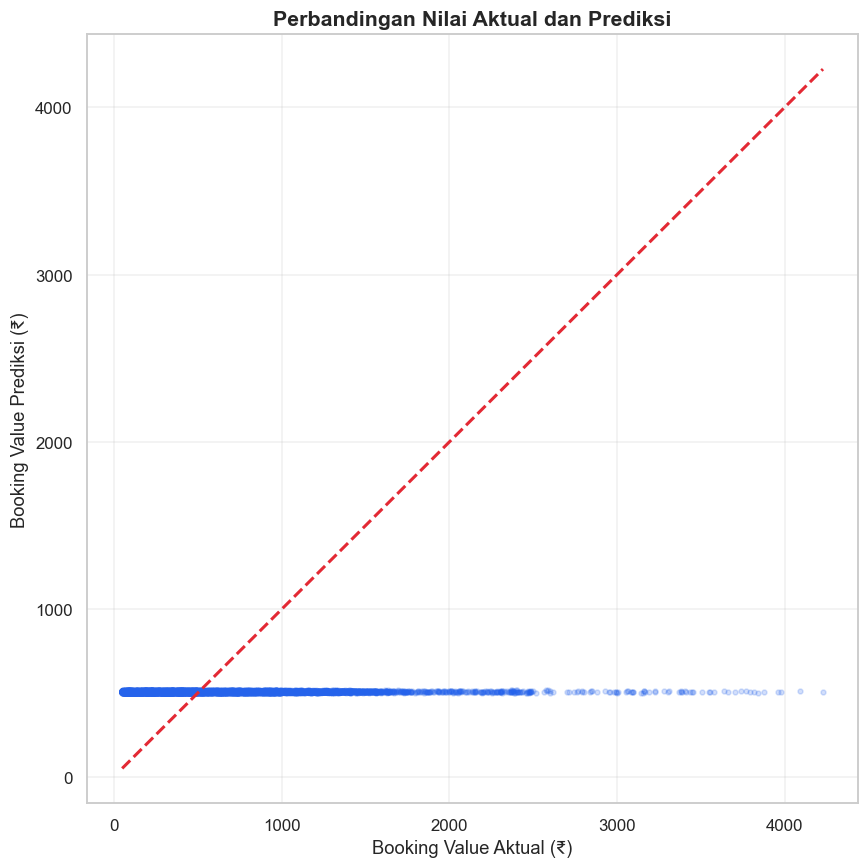

In [47]:
# Visualisasi hasil prediksi
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    y_test,
    y_pred,
    alpha=0.2,
    s=10,
    color=COLORS["primary"],
)

limits = [y_test.min(), y_test.max()]

ax.plot(
    limits,
    limits,
    color=COLORS["danger"],
    linestyle="--",
    linewidth=2,
)

ax.set_title("Perbandingan Nilai Aktual dan Prediksi")
ax.set_xlabel("Booking Value Aktual (₹)")
ax.set_ylabel("Booking Value Prediksi (₹)")

plt.tight_layout()
plt.show()

### 13.3 Booking Failure Prediction — Classification

Model klasifikasi dikembangkan untuk memprediksi kemungkinan suatu pemesanan **berhasil diselesaikan** atau **gagal** berdasarkan informasi yang tersedia pada saat pemesanan dibuat. Prediksi ini dapat dimanfaatkan untuk mendukung intervensi operasional, seperti prioritas alokasi pengemudi atau strategi mitigasi pembatalan.

Pada tahap ini dibandingkan beberapa algoritma klasifikasi, yaitu **Logistic Regression**, **Random Forest**, dan **Gradient Boosting**, kemudian dievaluasi menggunakan metrik **Accuracy**, **Precision**, **Recall**, **F1-Score**, dan **ROC-AUC** untuk menentukan model dengan performa terbaik.

In [48]:
# Menyiapkan data untuk klasifikasi
classification_data = df.copy()
classification_data["Failed"] = (~classification_data["is_completed"]).astype(int)

feature_columns = [
    "Vehicle Type",
    "Pickup Location",
    "Hour",
    "DOW",
    "is_weekend",
    "TimeOfDay",
]

X = classification_data[feature_columns].copy()
y = classification_data["Failed"]

categorical_features = [
    "Vehicle Type",
    "Pickup Location",
    "TimeOfDay",
]

numeric_features = [
    "Hour",
    "DOW",
    "is_weekend",
]

X["is_weekend"] = X["is_weekend"].astype(int)

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("numeric", "passthrough", numeric_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Model klasifikasi
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        max_depth=12,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=120,
        max_depth=4,
        random_state=42,
    ),
}

results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
    })

    trained_models[name] = pipeline

results_df = (
    pd.DataFrame(results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
    .round(4)
)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.62,0.42,0.00,0.00,0.50
1,Logistic Regression,0.50,0.38,0.48,0.42,0.50
2,Random Forest,0.52,0.38,0.42,0.40,0.50


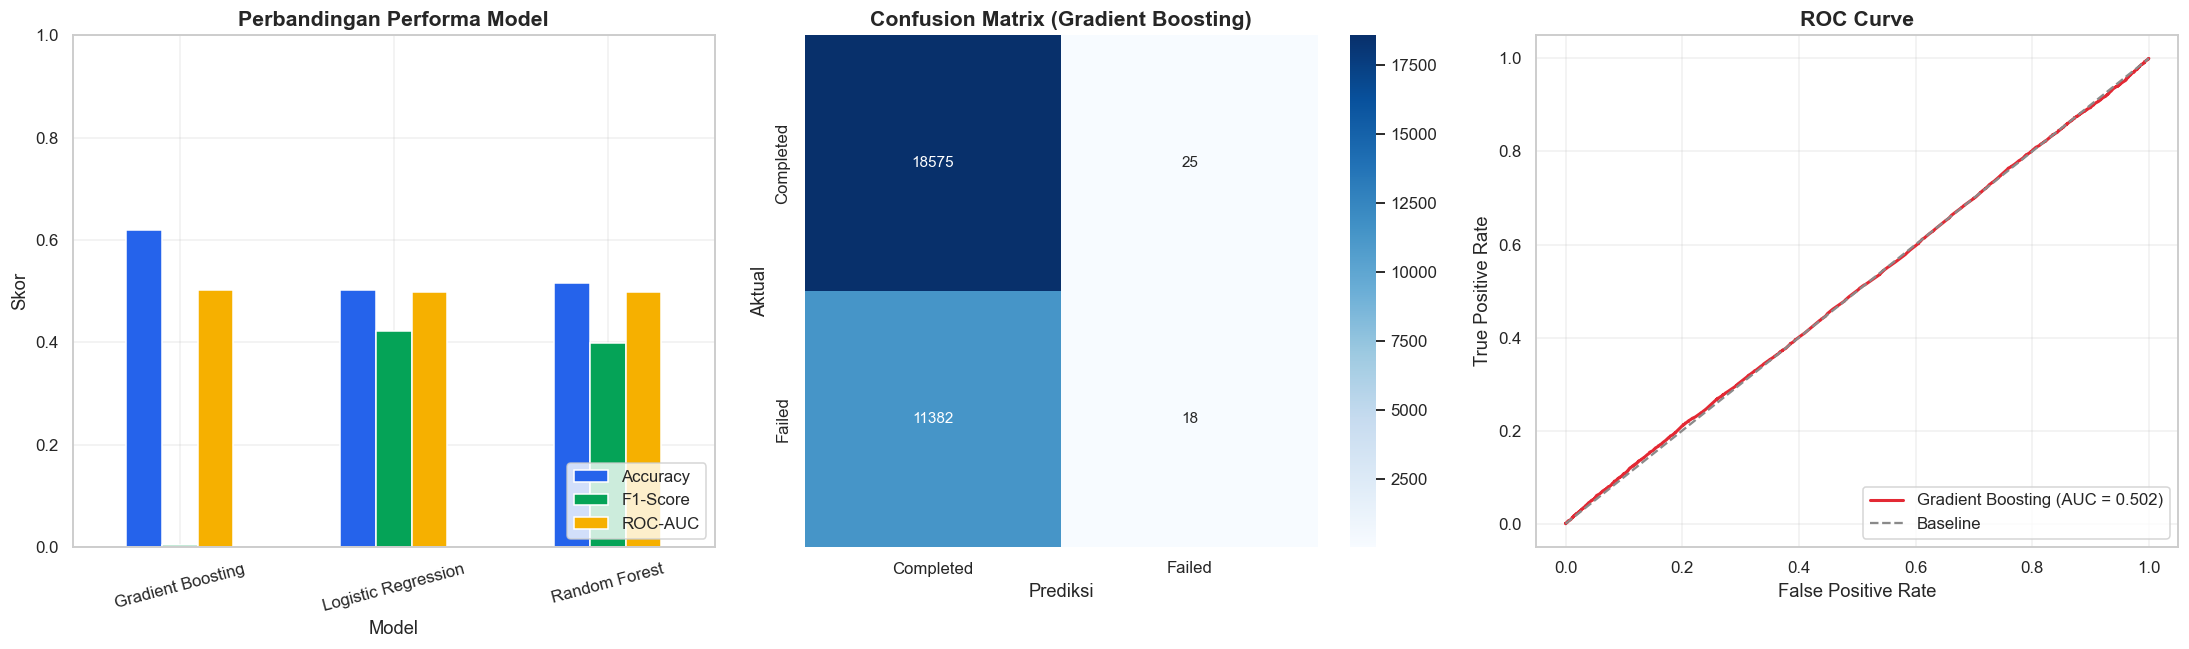

In [49]:
# Model terbaik berdasarkan ROC-AUC
best_model_name = results_df.loc[
    results_df["ROC-AUC"].idxmax(),
    "Model",
]

best_model = trained_models[best_model_name]

predictions = best_model.predict(X_test)
probabilities = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Perbandingan performa model
comparison = results_df.set_index("Model")[["Accuracy", "F1-Score", "ROC-AUC"]]

comparison.plot(
    kind="bar",
    ax=axes[0],
    color=[
        COLORS["primary"],
        COLORS["success"],
        COLORS["warning"],
    ],
)

axes[0].set_title("Perbandingan Performa Model")
axes[0].set_ylabel("Skor")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(loc="lower right")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, predictions)

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Completed", "Failed"],
    yticklabels=["Completed", "Failed"],
    ax=axes[1],
)

axes[1].set_title(f"Confusion Matrix ({best_model_name})")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Aktual")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, probabilities)

axes[2].plot(
    fpr,
    tpr,
    color=COLORS["danger"],
    linewidth=2,
    label=f"{best_model_name} (AUC = {roc_auc_score(y_test, probabilities):.3f})",
)

axes[2].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color=COLORS["neutral"],
    label="Baseline",
)

axes[2].set_title("ROC Curve")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

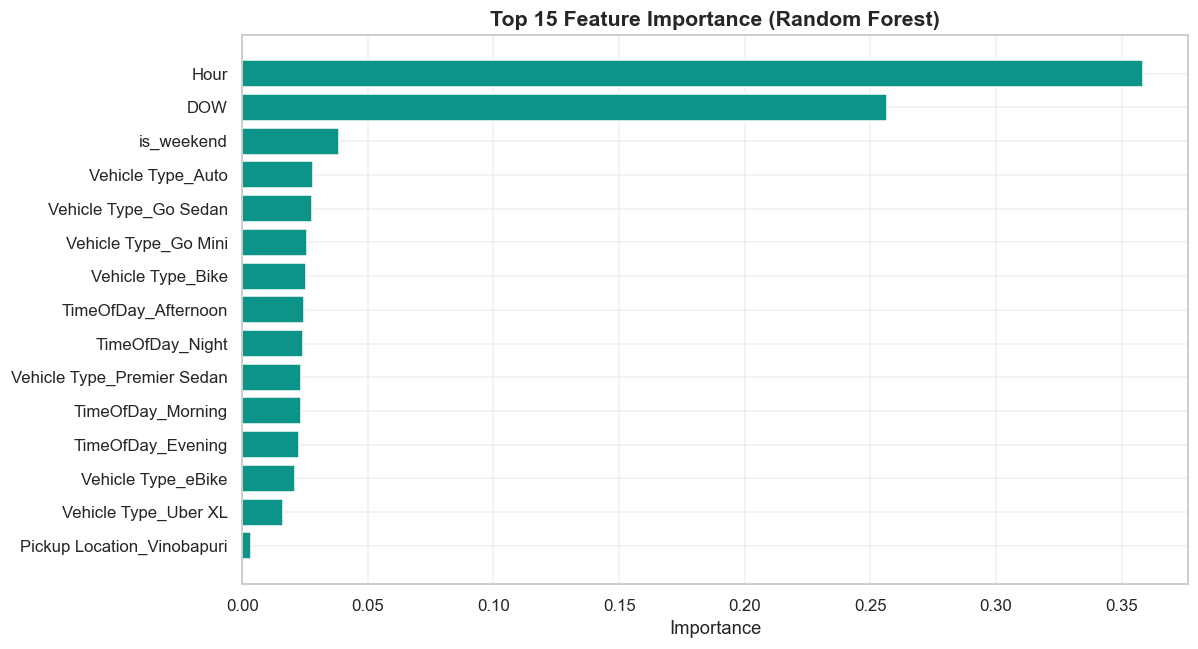

,Feature,Importance
187,Hour,0.36
188,DOW,0.26
189,is_weekend,0.04
0,Vehicle Type_Auto,0.03
3,Vehicle Type_Go Sedan,0.03
2,Vehicle Type_Go Mini,0.03
1,Vehicle Type_Bike,0.03
183,TimeOfDay_Afternoon,0.02
186,TimeOfDay_Night,0.02
4,Vehicle Type_Premier Sedan,0.02


In [50]:
# Feature importance dari Random Forest
random_forest = trained_models["Random Forest"]

encoder = random_forest.named_steps["preprocessor"].named_transformers_["categorical"]

feature_names = (
    list(encoder.get_feature_names_out(categorical_features))
    + numeric_features
)

feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": random_forest.named_steps["model"].feature_importances_,
    })
    .sort_values("Importance", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1],
    color=COLORS["teal"],
)

ax.set_title("Top 15 Feature Importance (Random Forest)")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

feature_importance

### 13.4 Time Series Forecasting — Peramalan Permintaan Harian

Analisis deret waktu dilakukan untuk memahami pola dan tren permintaan harian serta menghasilkan proyeksi jumlah pemesanan pada periode mendatang. Pendekatan yang digunakan meliputi **dekomposisi deret waktu**, **moving average**, dan analisis **autokorelasi** untuk mendukung perencanaan kapasitas operasional.

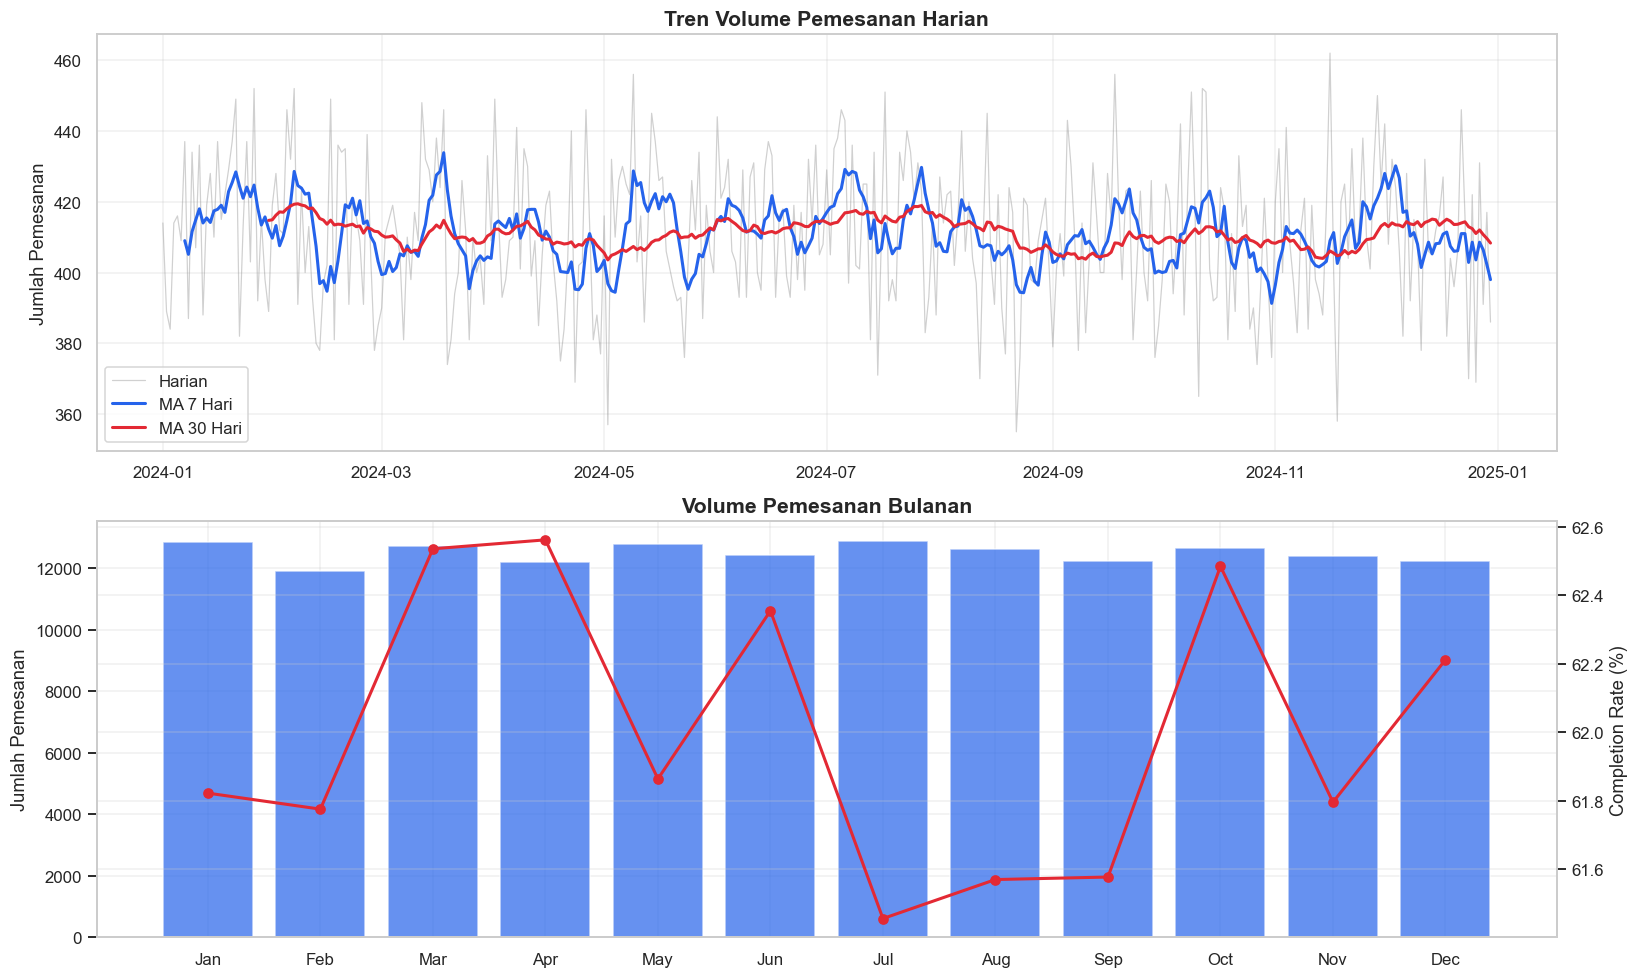

,Rata-rata Pemesanan per Hari,Standar Deviasi,Hari Tersibuk,Hari Tersepi
0,411,21,16 Nov 2024 (462),22 Aug 2024 (355)


In [51]:
# Volume pemesanan harian
daily_bookings = (
    df.set_index("Datetime")
      .resample("D")
      .size()
)

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Tren harian dengan moving average
axes[0].plot(
    daily_bookings.index,
    daily_bookings.values,
    color=COLORS["neutral"],
    alpha=0.4,
    linewidth=0.8,
    label="Harian",
)

axes[0].plot(
    daily_bookings.index,
    daily_bookings.rolling(7).mean(),
    color=COLORS["primary"],
    linewidth=2,
    label="MA 7 Hari",
)

axes[0].plot(
    daily_bookings.index,
    daily_bookings.rolling(30).mean(),
    color=COLORS["danger"],
    linewidth=2,
    label="MA 30 Hari",
)

axes[0].set_title("Tren Volume Pemesanan Harian")
axes[0].set_ylabel("Jumlah Pemesanan")
axes[0].legend()

# Ringkasan bulanan
monthly_summary = (
    df.set_index("Datetime")
      .resample("ME")
      .agg(
          Total_Bookings=("Booking ID", "size"),
          Completion_Rate=("is_completed", "mean"),
      )
)

axes[1].bar(
    monthly_summary.index.strftime("%b"),
    monthly_summary["Total_Bookings"],
    color=COLORS["primary"],
    alpha=0.7,
)

axes[1].set_title("Volume Pemesanan Bulanan")
axes[1].set_ylabel("Jumlah Pemesanan")

ax2 = axes[1].twinx()

ax2.plot(
    monthly_summary.index.strftime("%b"),
    monthly_summary["Completion_Rate"] * 100,
    color=COLORS["danger"],
    marker="o",
    linewidth=2,
)

ax2.set_ylabel("Completion Rate (%)")

plt.tight_layout()
plt.show()

# Ringkasan statistik
pd.DataFrame({
    "Rata-rata Pemesanan per Hari": [round(daily_bookings.mean())],
    "Standar Deviasi": [round(daily_bookings.std())],
    "Hari Tersibuk": [
        f"{daily_bookings.idxmax():%d %b %Y} ({daily_bookings.max():,})"
    ],
    "Hari Tersepi": [
        f"{daily_bookings.idxmin():%d %b %Y} ({daily_bookings.min():,})"
    ],
})

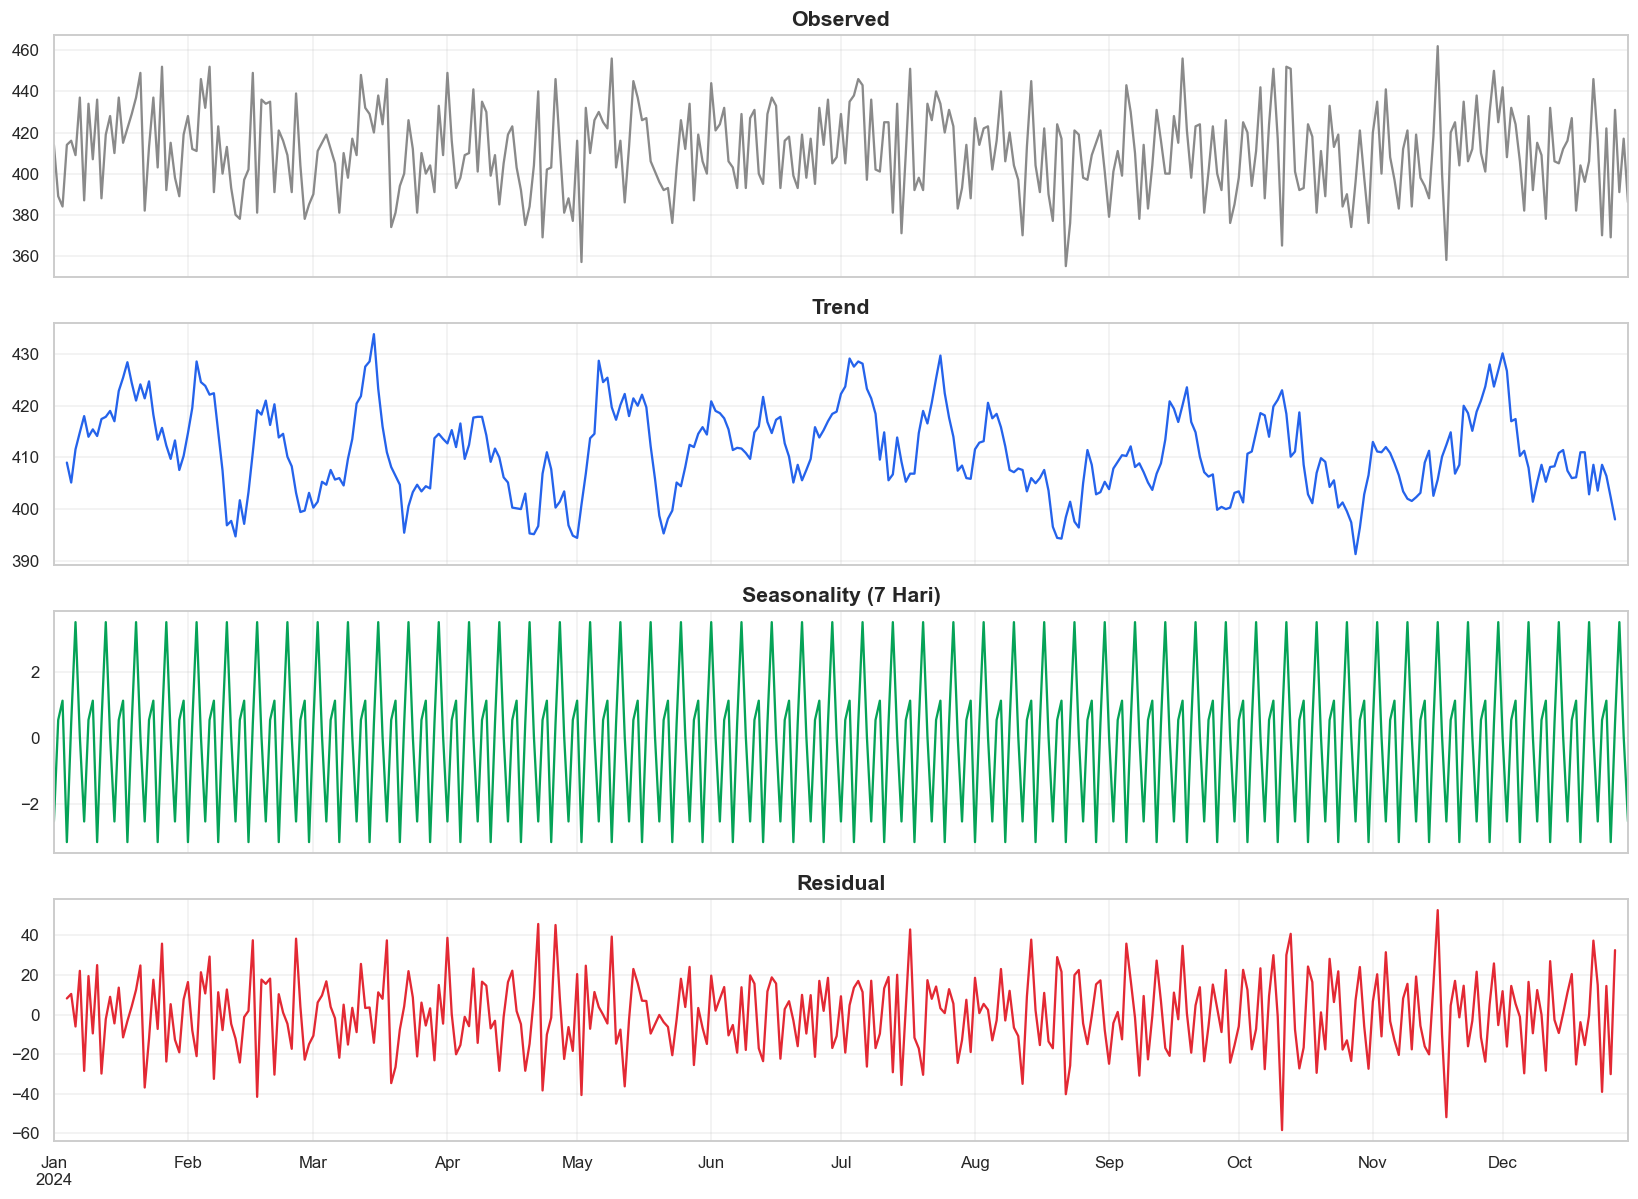

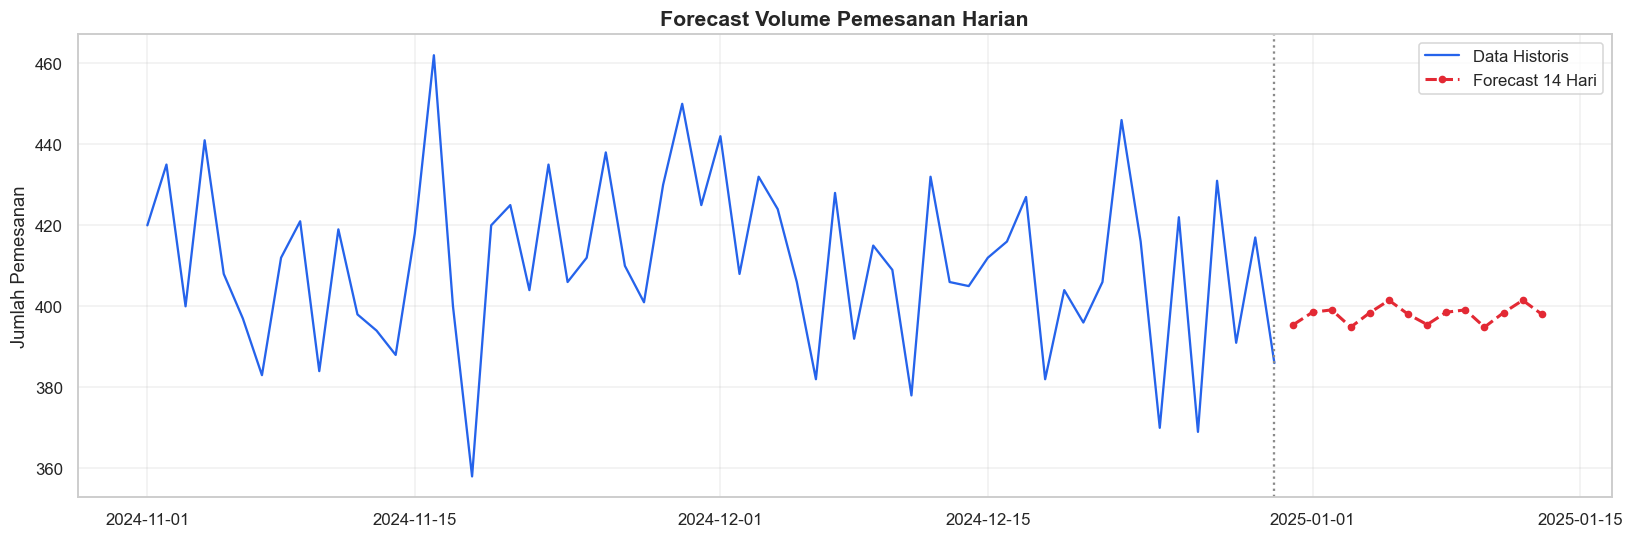

,Periode Forecast,Rata-rata Pemesanan per Hari
0,14 Hari,398


In [52]:
# Dekomposisi time series
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    daily_bookings,
    model="additive",
    period=7,
)

fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)

decomposition.observed.plot(
    ax=axes[0],
    color=COLORS["neutral"],
    title="Observed",
)

decomposition.trend.plot(
    ax=axes[1],
    color=COLORS["primary"],
    title="Trend",
)

decomposition.seasonal.plot(
    ax=axes[2],
    color=COLORS["success"],
    title="Seasonality (7 Hari)",
)

decomposition.resid.plot(
    ax=axes[3],
    color=COLORS["danger"],
    title="Residual",
)

for ax in axes:
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

# Forecast sederhana 14 hari
last_trend = decomposition.trend.dropna().iloc[-1]
seasonal_pattern = decomposition.seasonal.iloc[:7].values

forecast_days = 14

future_dates = pd.date_range(
    daily_bookings.index[-1] + pd.Timedelta(days=1),
    periods=forecast_days,
)

forecast = [
    last_trend + seasonal_pattern[i % 7]
    for i in range(forecast_days)
]

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    daily_bookings.index[-60:],
    daily_bookings.values[-60:],
    color=COLORS["primary"],
    label="Data Historis",
)

ax.plot(
    future_dates,
    forecast,
    color=COLORS["danger"],
    linestyle="--",
    marker="o",
    linewidth=2,
    markersize=4,
    label="Forecast 14 Hari",
)

ax.axvline(
    daily_bookings.index[-1],
    color=COLORS["neutral"],
    linestyle=":",
)

ax.set_title("Forecast Volume Pemesanan Harian")
ax.set_ylabel("Jumlah Pemesanan")
ax.legend()

plt.tight_layout()
plt.show()

# Ringkasan forecast
pd.DataFrame({
    "Periode Forecast": [f"{forecast_days} Hari"],
    "Rata-rata Forecast": [round(np.mean(forecast))],
}).rename(columns={"Rata-rata Forecast": "Rata-rata Pemesanan per Hari"})

# 14. Export Dataset & Data Modeling

Pada tahap akhir, dataset yang telah melalui proses pembersihan dan *feature engineering* diekspor ke beberapa format serta disusun ke dalam **star schema** untuk mendukung analisis lanjutan dan pengembangan dashboard.

In [53]:
# Memilih kolom untuk dataset akhir
export_columns = [
    "Booking ID", "Datetime", "Date", "Time", "Hour", "Weekday", "Month",
    "TimeOfDay", "Period", "is_weekend", "Booking Status", "Outcome",
    "StatusCategory", "is_completed", "is_cancelled", "Customer ID",
    "Vehicle Type", "Pickup Location", "Drop Location", "Route",
    "Avg VTAT", "Avg CTAT", "Booking Value", "Ride Distance", "PricePerKm",
    "DistanceBand", "RevenueBand", "Driver Ratings", "Customer Rating",
    "Payment Method", "Driver Cancellation Reason",
    "Reason for cancelling by Customer", "Incomplete Rides Reason",
]

clean_dataset = df[export_columns].copy()

# Ekspor dataset
clean_dataset.to_csv("clean_dataset.csv", index=False)

clean_dataset.to_excel(
    "clean_dataset.xlsx",
    sheet_name="bookings",
    index=False,
)

# Simpan ke SQLite
sql_dataset = clean_dataset.copy()
sql_dataset.columns = sql_dataset.columns.str.replace(" ", "_")
sql_dataset["Datetime"] = sql_dataset["Datetime"].astype(str)

sql_dataset.to_sql(
    "clean_bookings",
    connection,
    if_exists="replace",
    index=False,
)

# Preview dataset
clean_dataset.head()

,Booking ID,Datetime,Date,Time,Hour,Weekday,Month,TimeOfDay,Period,is_weekend,Booking Status,Outcome,StatusCategory,is_completed,is_cancelled,Customer ID,Vehicle Type,Pickup Location,Drop Location,Route,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,PricePerKm,DistanceBand,RevenueBand,Driver Ratings,Customer Rating,Payment Method,Driver Cancellation Reason,Reason for cancelling by Customer,Incomplete Rides Reason
0,CNR5884300,2024-03-23 12:29:38,2024-03-23,12:29:38,12,Saturday,March,Afternoon,Off-Peak,True,No Driver Found,No Driver Found,Failed - Supply,False,False,CID1982111,eBike,Palam Vihar,Jhilmil,Palam Vihar → Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CNR1326809,2024-11-29 18:01:39,2024-11-29,18:01:39,18,Friday,November,Evening,Peak,False,Incomplete,Incomplete,Failed - Mid-Ride,False,False,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,Shastri Nagar → Gurgaon Sector 56,4.90,14.00,237.00,5.73,41.36,0–10 km,Low,NaN,NaN,UPI,NaN,NaN,Vehicle Breakdown
2,CNR8494506,2024-08-23 08:56:10,2024-08-23,08:56:10,8,Friday,August,Morning,Peak,False,Completed,Completed,Success,True,False,CID9202816,Auto,Khandsa,Malviya Nagar,Khandsa → Malviya Nagar,13.40,25.80,627.00,13.58,46.17,10–20 km,High,4.90,4.90,Debit Card,NaN,NaN,NaN
3,CNR8906825,2024-10-21 17:17:25,2024-10-21,17:17:25,17,Monday,October,Evening,Peak,False,Completed,Completed,Success,True,False,CID2610914,Premier Sedan,Central Secretariat,Inderlok,Central Secretariat → Inderlok,13.10,28.50,416.00,34.02,12.23,>30 km,Medium,4.60,5.00,UPI,NaN,NaN,NaN
4,CNR1950162,2024-09-16 22:08:00,2024-09-16,22:08:00,22,Monday,September,Night,Off-Peak,False,Completed,Completed,Success,True,False,CID9933542,Bike,Ghitorni Village,Khan Market,Ghitorni Village → Khan Market,5.30,19.60,737.00,48.21,15.29,>30 km,High,4.10,4.30,UPI,NaN,NaN,NaN
